# Модели временных рядов (базовый)



## **Цели занятия**

+ понять базовые принципы построения моделей временных рядов
+ какие основные свойства финансовых рядов мы пытаемся моделировать
+ понять, что такое серийная корреляция
+ понять структуру модели случайного блуждания (RW)
+ изучить идентификацию параметров модели с помощью коррелограмм (ACF, PACF)
+ понять базовые принципы авторегрессионных (AR) моделей
+ научиться строить AR-модели в Python
+ понять базовые принципы моделей скользящего среднего (MA)
+ научиться строить AR/MA/ARMA модели финансовых рядов в Python
+ понять принципы применения критериев AIC/BIC для выбора модели
+ научиться строить прогнозы для ARMA-моделей
+ понять, что такое условная гетероскедастичность
+ научиться оценивать ARCH-эффект
+ строить ARCH/GARCH модели в Python

In [ ]:
#!pip install statsmodels
#!pip install apimoex


In [1]:
import pandas as pd
import numpy as np
from datetime import date
import apimoex
import requests
import moex_utils as moex

import matplotlib.pyplot as plt

import statsmodels as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA

import statsmodels.tsa.api as smt
import scipy.stats as scs

### Что такое модель?

+ При работе с финансовыми данными мы обычно хотим их предсказывать или симулировать (например, для риск-менеджмента). Для прогнозов или симуляций нужна **модель** данных (ряда).
+ Модель по определению - упрощённое представление реальности. Мы хотим, чтобы модели отражали свойства ряда, наблюдаемые эмпирически.
+ Модели финансовых рынков должны учитывать свойства финансовых данных.

## Основные свойства финансовых рядов

1. Многие финансовые ряды растут **экспоненциально** и имеют меняющуюся волатильность в зависимости от уровня.
2. Близкие по времени наблюдения коррелированы друг с другом.
3. Доходности имеют избыточный эксцесс (**тяжёлые хвосты**) и **НЕ** распределены нормально.
4. Волатильность персистентна; часто наблюдаются **кластеры волатильности** - периоды высокой и низкой волатильности сохраняются во времени.

In [2]:
# moex_utils должен быть в текущей директории (ipynb/)
import sys
from pathlib import Path
for d in [Path('.'), Path('ipynb'), Path.cwd()]:
    if (d / 'moex_utils.py').exists():
        sys.path.insert(0, str(d.resolve()))
        break
from moex_utils import get_moex_stock, get_moex_index


In [3]:
today = date.today()
df = get_moex_index("MCFTRN", start = '2010-01-01', end = today)
df.index = pd.DatetimeIndex(df.index).to_period('D')
df.tail()

,BOARDID,close,VOLUME,volume
date,,,,
2026-01-29,RTSI,6492.32,3.204859e+10,1.432966e+11
2026-01-30,RTSI,6457.47,7.631976e+09,7.332835e+10
2026-02-02,RTSI,6424.56,6.203583e+09,6.578454e+10
2026-02-03,RTSI,6465.38,7.218003e+09,6.114018e+10
2026-02-04,RTSI,6442.55,9.750274e+09,6.670519e+10


In [4]:
df['log_rtns'] = np.log(df['close']) - np.log(df['close'].shift(1))

In [5]:
df

,BOARDID,close,VOLUME,volume,log_rtns
date,,,,,
2010-01-11,RTSI,1548.97,NaN,0.000000e+00,NaN
2010-01-12,RTSI,1530.62,NaN,0.000000e+00,-0.011917
2010-01-13,RTSI,1538.49,NaN,0.000000e+00,0.005129
2010-01-14,RTSI,1560.62,NaN,0.000000e+00,0.014282
2010-01-15,RTSI,1557.43,NaN,0.000000e+00,-0.002046
...,...,...,...,...,...
2026-01-29,RTSI,6492.32,3.204859e+10,1.432966e+11,0.003492
2026-01-30,RTSI,6457.47,7.631976e+09,7.332835e+10,-0.005382
2026-02-02,RTSI,6424.56,6.203583e+09,6.578454e+10,-0.005109


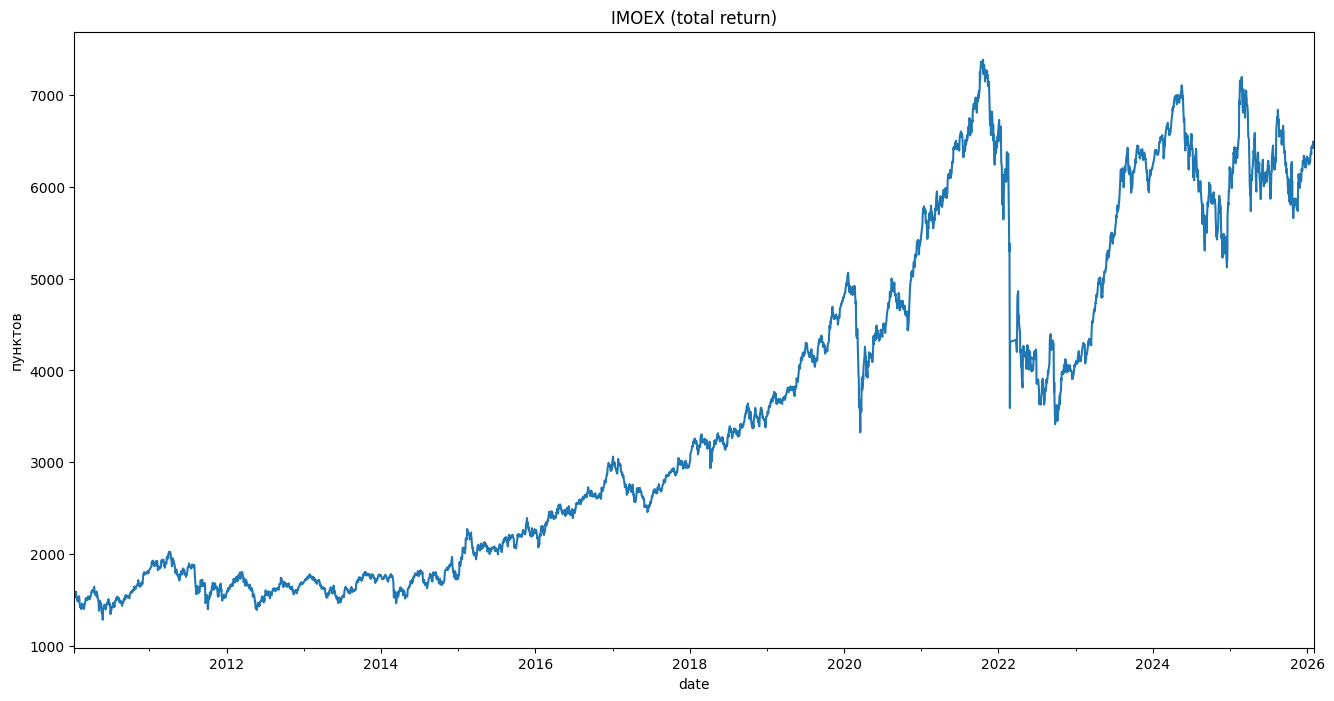

In [6]:
df['close'].plot(figsize=(16,8))
plt.ylabel('пунктов')
plt.title ('IMOEX (total return)')
plt.show()

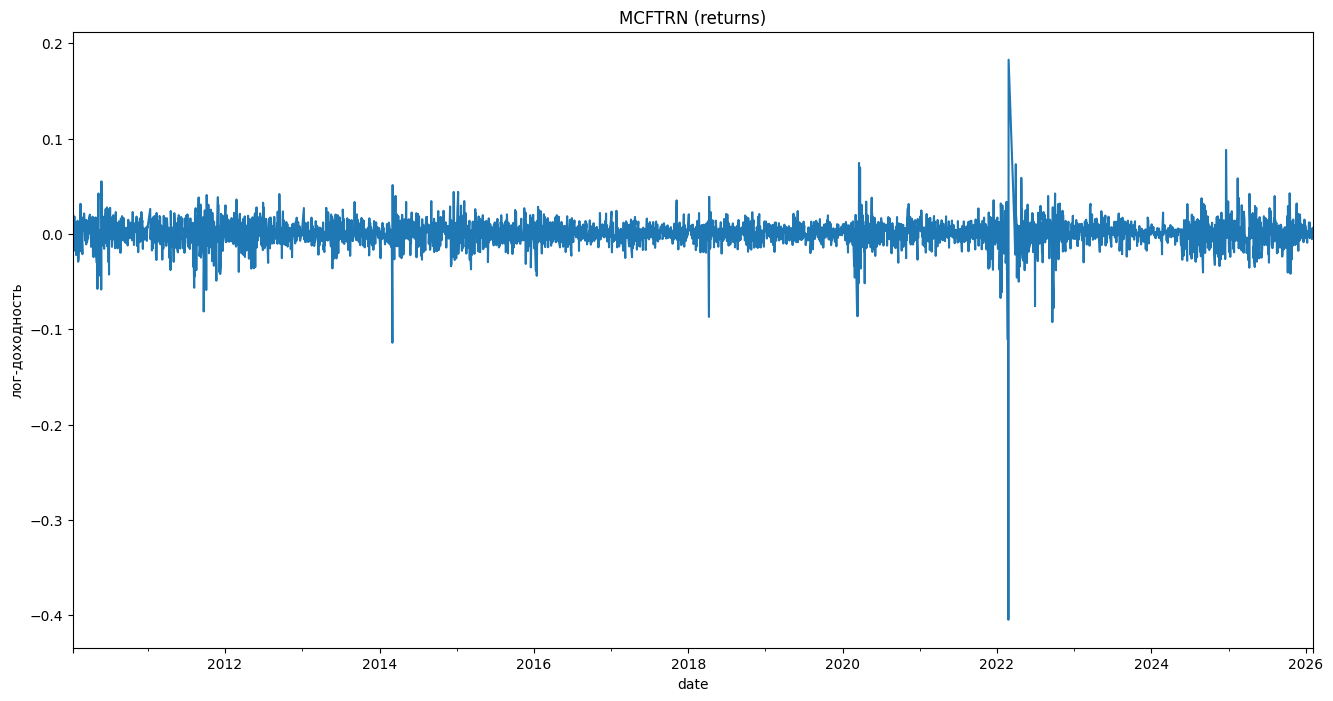

In [7]:
df['log_rtns'].plot(figsize=(16,8))
plt.ylabel('лог-доходность')
plt.title ('MCFTRN (returns)')
plt.show()

In [8]:
# Удаляем колонку объёма, если есть (moex_utils возвращает 'volume')
for col in ['VOLUME', 'volume']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        break

In [9]:
#df.index = df.index .to_timestamp()
df['year'] = df.index.year

In [10]:
df

,BOARDID,close,volume,log_rtns,year
date,,,,,
2010-01-11,RTSI,1548.97,0.000000e+00,NaN,2010
2010-01-12,RTSI,1530.62,0.000000e+00,-0.011917,2010
2010-01-13,RTSI,1538.49,0.000000e+00,0.005129,2010
2010-01-14,RTSI,1560.62,0.000000e+00,0.014282,2010
2010-01-15,RTSI,1557.43,0.000000e+00,-0.002046,2010
...,...,...,...,...,...
2026-01-29,RTSI,6492.32,1.432966e+11,0.003492,2026
2026-01-30,RTSI,6457.47,7.332835e+10,-0.005382,2026
2026-02-02,RTSI,6424.56,6.578454e+10,-0.005109,2026


In [11]:
day_per_year =  df.groupby(df.index.year).size()
day_per_year # количество торговых дней в каждом 

date
2010    248
2011    248
2012    255
2013    250
2014    250
2015    250
2016    252
2017    252
2018    254
2019    252
2020    250
2021    255
2022    233
2023    254
2024    256
2025    254
2026     22
dtype: int64

In [12]:
day_per_year.iloc[:-1].mean()

np.float64(250.8125)

In [13]:
np.mean(df["log_rtns"]) * 251

np.float64(0.08868589287837506)

In [14]:
np.std(df["log_rtns"]) * np.sqrt(250) # s.d on returns

np.float64(0.23634562435886988)

In [22]:
type(df["close"])

pandas.core.series.Series

In [15]:
import ffn 
stats = df["close"].to_timestamp().calc_stats() #  индекс у df имеет тип Period (после to_period('D')), а ffn.calc_stats() ожидает DatetimeIndex.

In [16]:
stats.display()

Stats for close from 2010-01-11 00:00:00 - 2026-02-04 00:00:00
Annual risk-free rate considered: 0.00%
Summary:
Total Return      Sharpe  CAGR    Max Drawdown
--------------  --------  ------  --------------
315.92%             0.51  9.28%   -53.74%

Annualized Returns:
mtd     3m     6m     ytd    1y     3y      5y     10y     incep.
------  -----  -----  -----  -----  ------  -----  ------  --------
-0.23%  9.67%  2.32%  1.78%  2.04%  14.44%  2.88%  10.82%  9.28%

Periodic:
        daily    monthly    yearly
------  -------  ---------  --------
sharpe  0.51     0.55       0.48
mean    11.66%   11.06%     10.39%
vol     23.03%   19.98%     21.77%
skew    -2.80    -0.90      -0.17
kurt    81.83    4.26       0.74
best    20.04%   17.99%     52.31%
worst   -33.28%  -30.02%    -38.17%

Drawdowns:
max      avg       # days
-------  ------  --------
-53.74%  -3.40%     49.62

Misc:
---------------  ------
avg. up month    4.19%
avg. down month  -4.70%
up year %        75.00%
12m up %      

In [17]:
stats.display_monthly_returns()

  Year    Jan     Feb    Mar    Apr     May    Jun    Jul    Aug     Sep    Oct    Nov    Dec     YTD
------  -----  ------  -----  -----  ------  -----  -----  -----  ------  -----  -----  -----  ------
  2010  -1.6    -6.11   8.82  -0.97   -7.2   -1.7    6.74  -1.83    5.22   5.77   2.77   8.1    17.66
  2011   3       3.18   2.01  -3.96   -4.34   0.03   2.49  -8.15  -11.61   9.7    0.1   -6.45  -14.83
  2012   7.97    5.63  -5.03  -2.89  -11.34   6.27   1.74   3.22    2.59  -2.05  -1.37   4.93    8.22
  2013   4.99   -3.6   -3.19  -3.66   -2.58  -1.41   3.82   1.45    7.21   3.53  -1.95   1.68    5.66
  2014  -3.26   -0.34  -5.22  -4.56    9.65   4.05  -4.55   1.53    0.76   5.69   3.17  -8.11   -2.66
  2015  17.99    6.75  -7.55   3.92   -4.29   3.19   3.15   3.84   -5.02   4.4    3.48  -0.02   31.33
  2016   1.47    3.1    1.68   4.47   -2.66   0.14   5.08   1.4     0.44   0.78   5.79   6.68   31.86
  2017  -0.66   -8.19  -1.96   1.1    -5.6    0      4.37   5.38    2.89  -0.3    

In [ ]:
stats.stats 

start                    2010-01-11 00:00:00
end                      2026-02-02 00:00:00
rf                                       0.0
total_return                         0.91625
cagr                                0.041327
max_drawdown                       -0.552895
calmar                              0.074746
mtd                                -0.005096
three_month                         0.093143
six_month                           0.014875
ytd                                 0.000701
one_year                             -0.0609
three_year                          0.072588
five_year                          -0.038002
ten_year                             0.04644
incep                               0.041327
daily_sharpe                        0.295847
daily_sortino                       0.433698
daily_mean                          0.068219
daily_vol                           0.230587
daily_skew                         -2.773511
daily_kurt                         81.358171
best_day  

<Axes: title={'center': 'close Return Histogram'}, ylabel='Density'>

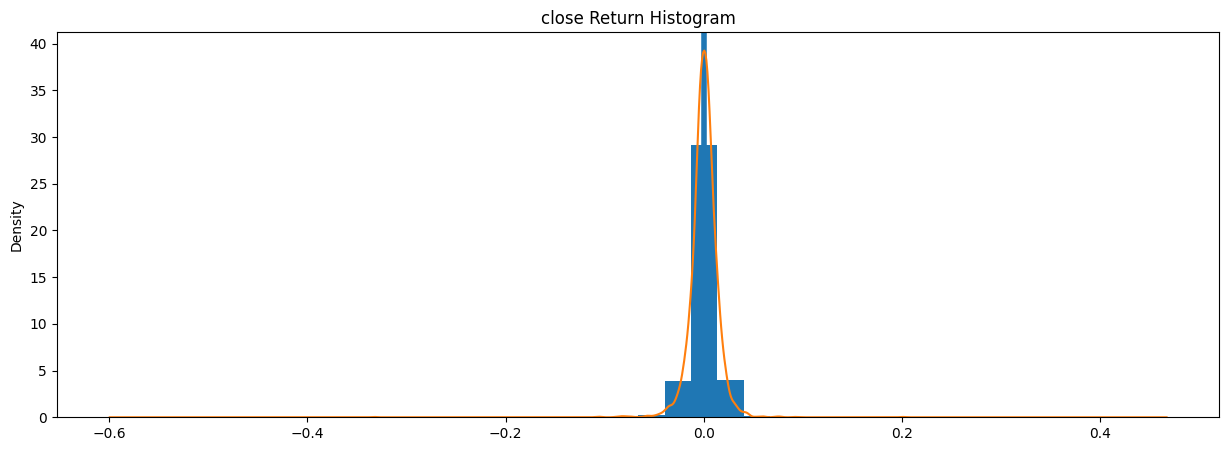

In [30]:
stats.plot_histogram()


## ЗАДАНИЕ 1 

1. Рассчитайте лог-доходности для своего тикера. Оптимально использовать adj close 
2. Посчитайте базовые статистики для свеого тикера с помощью `calc_stats()`
3. Постройте показатели `stats.stats` и изучите, что они означают? 

### Серийная корреляция

+ В финансовых рядах последовательные наблюдения часто влияют друг на друга - они коррелированы. С количественной точки зрения задача - выявить и структурировать эти корреляции.
+ Эту зависимость можно представить как распространение информации. Инвесторам нужно время на оценку и интерпретацию. Поэтому доходность в момент $t$ может быть связана с доходностью в $t-1$. В ряде сохраняется «память».
+ Адекватное моделирование этой корреляции может существенно улучшить прогнозные способности моделей.
+ Если последовательные наблюдения во временном ряде коррелированы, говорят о **серийной корреляции** (или **автокорреляции**).

Serial correlation ($\rho_k$)  at $k$ lag  is defined **autocovariance** normalised by dispersion:

$$\rho_k = \frac{C_k}{\sigma^2} $$

**autocovariance** of time series at lag $k$ is defined as:

$$C_k = E[(x_t - \mu)(x_{t+k}-\mu)] $$

where $\mu$ -- is the mean. Covariance determines the degree of **linear dependence** between variables. That is, covariance tells how much the variables change together. Correlation may not take into account the non-linear relationship that exists in the series.

In practice, we do not know the true values of these parameters (mean, variance, covariance) and have to estimate sample values based on the available data.

### Коррелограмма

+ **Коррелограмма** - график автокорреляций при последовательных лагах. Позволяет наглядно увидеть структуру автокорреляции.
+ Основное применение - визуальный поиск автокорреляции. Затем мы «подгоним» её с помощью модели.
+ Коррелограмма остатков модели позволяет оценить «остаточную» автокорреляцию и понять, нужны ли доработки модели.
+ Для построения ACF в Python используйте функцию `plot_acf`.

In [34]:
df

,BOARDID,close,volume,log_rtns,year
date,,,,,
2010-01-11,SNDX,1444.78,5.205232e+10,NaN,2010
2010-01-12,SNDX,1427.67,3.882154e+10,-0.011913,2010
2010-01-13,SNDX,1435.01,4.222875e+10,0.005128,2010
2010-01-14,SNDX,1455.65,4.451159e+10,0.014281,2010
2010-01-15,SNDX,1452.67,4.267554e+10,-0.002049,2010
...,...,...,...,...,...
2026-01-27,SNDX,2781.39,6.227600e+10,0.004772,2026
2026-01-28,SNDX,2788.01,5.867271e+10,0.002377,2026
2026-01-29,SNDX,2797.76,1.432966e+11,0.003491,2026


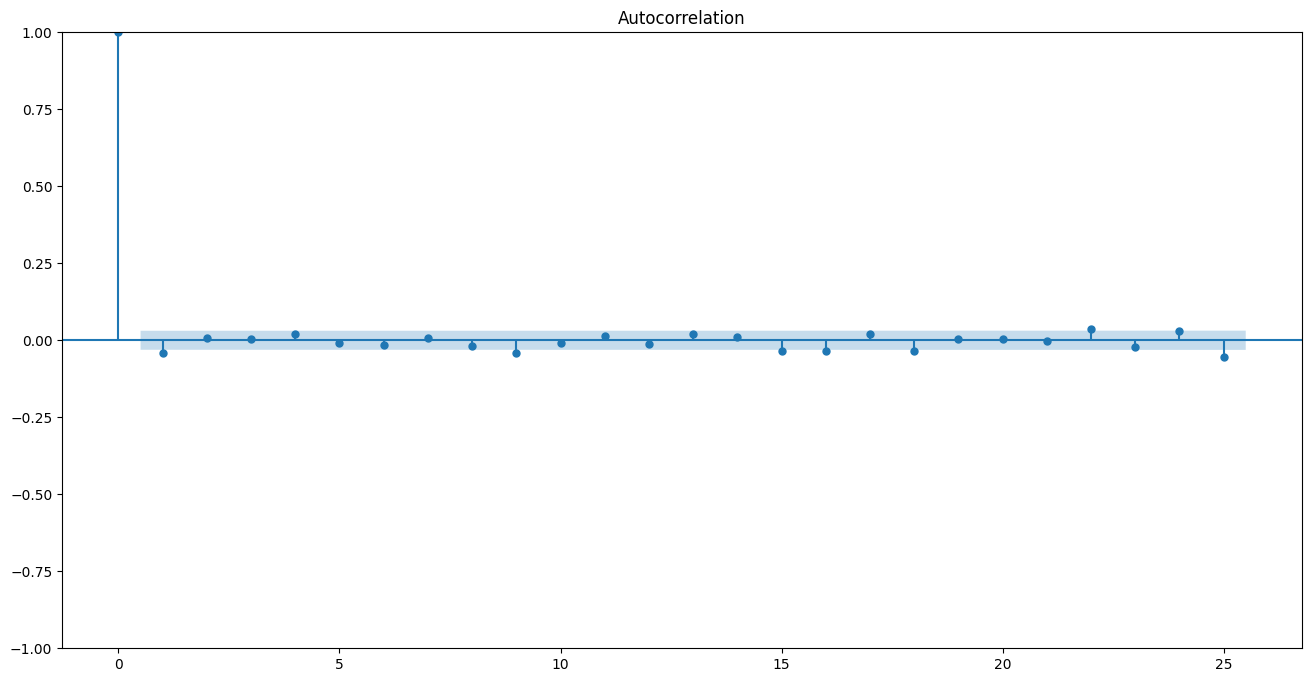

In [36]:
from statsmodels.graphics.tsaplots import plot_acf

# you need to remove NaN!
plt.rc("figure", figsize=(16,8))
fig = plot_acf(df['log_rtns'].dropna().values.squeeze(), lags=25)
plt.show()

ACF для случайной нормально распределённой серии

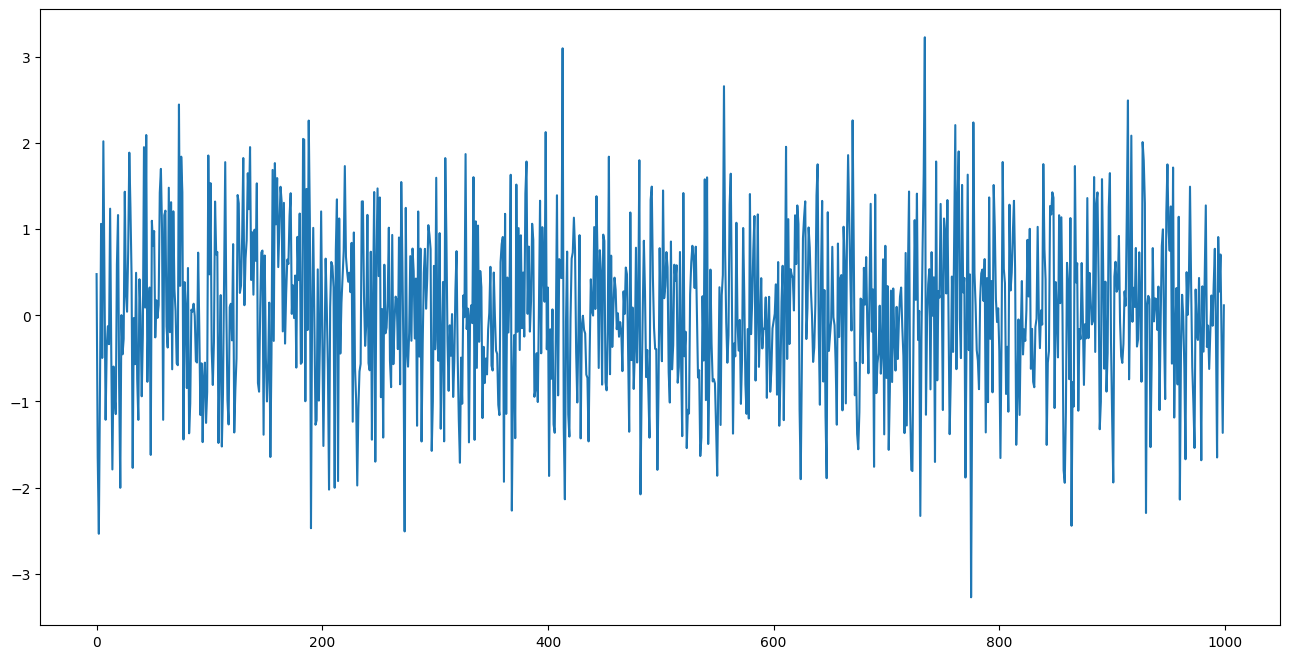

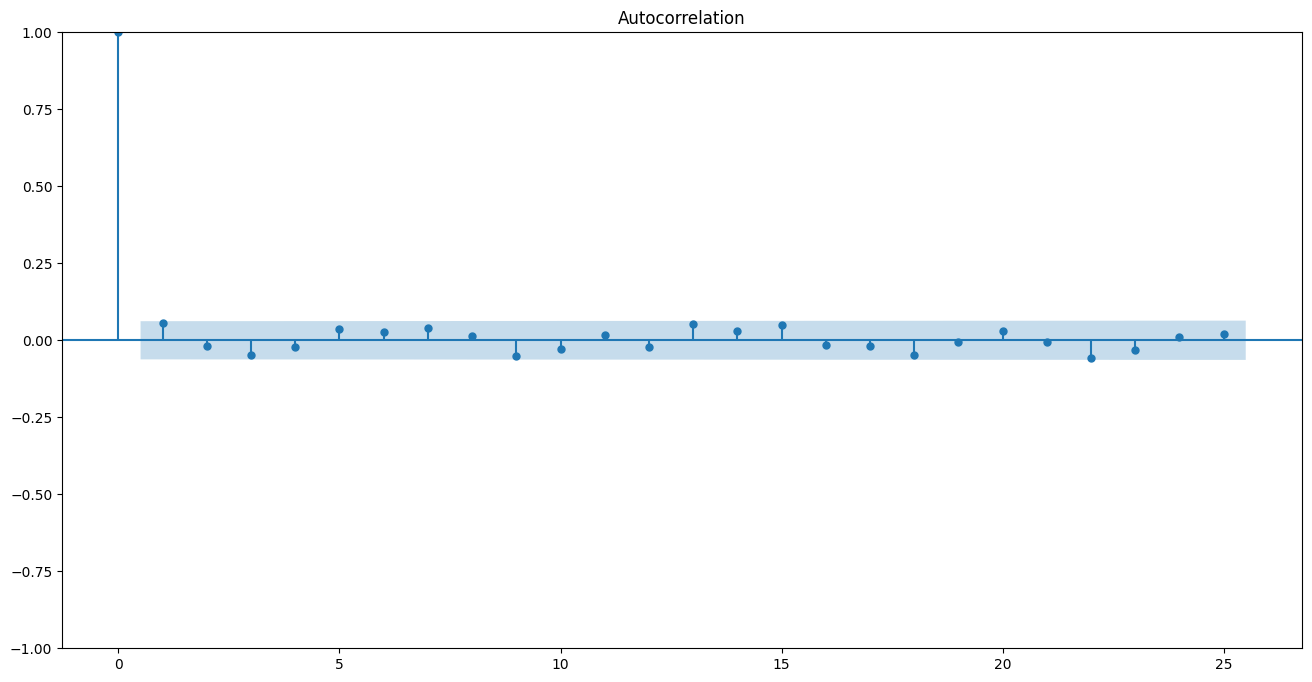

In [35]:
mu, sigma = 0, 1 # mean and standard deviation
X = np.random.normal(mu, sigma, 1000) # draw samples from normal distribution
plt.figure(figsize=[16, 8])
plt.plot(X)
fig = plot_acf(X, lags = 25)

ACF для линейного тренда

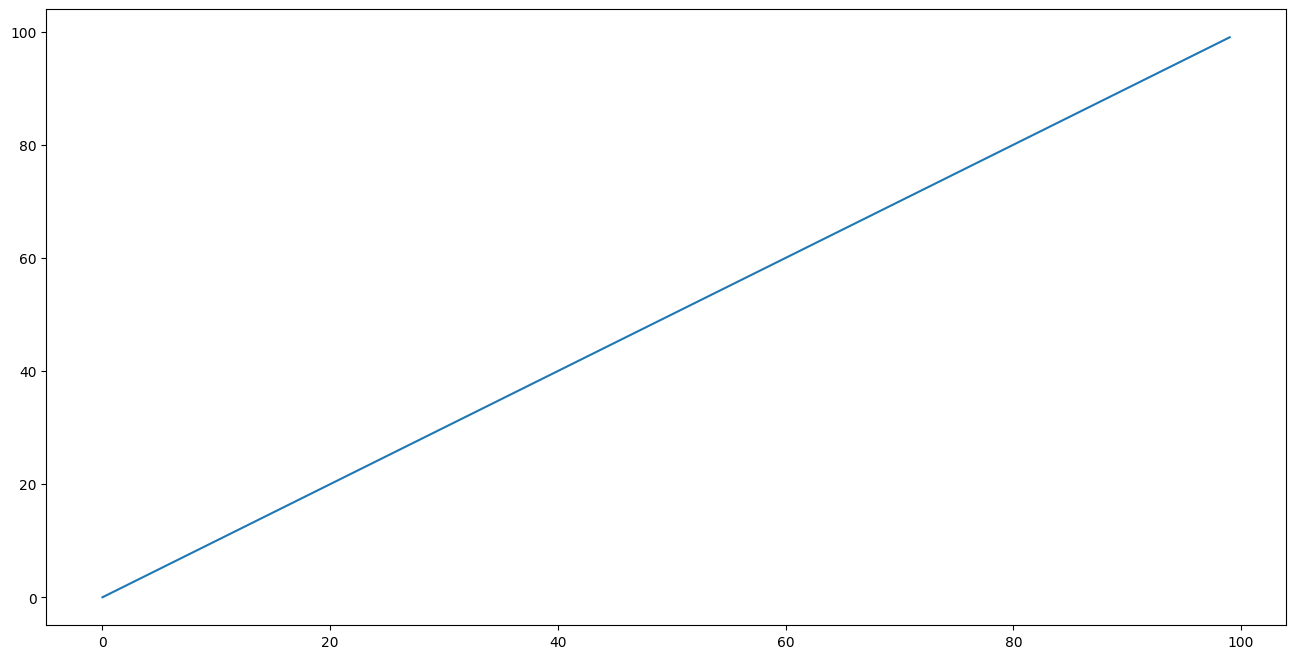

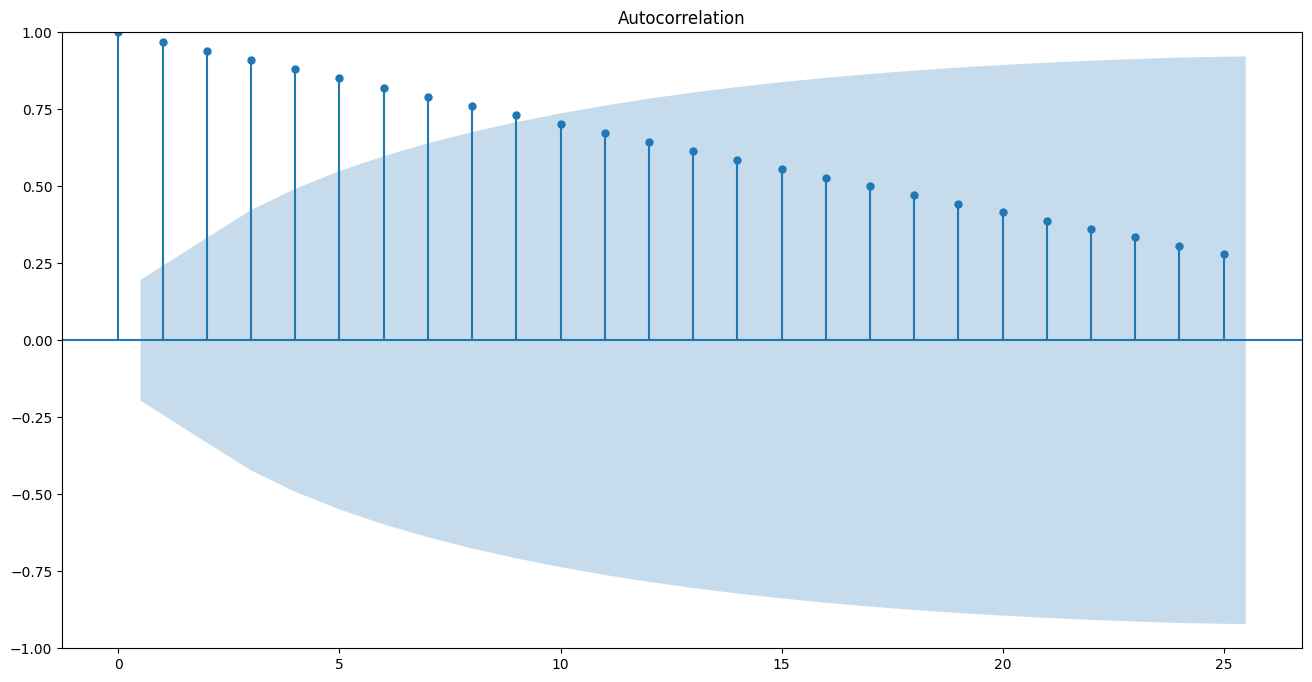

In [37]:
X = np.arange(0, 100, 1)
plt.figure(figsize=[16, 8])
plt.plot(X)
fig = plot_acf(X, lags = 25)

ACF для повторяющейся последовательности

In [ ]:
X = list(np.arange(0, 12, 1)) * 10
plt.figure(figsize=[16, 8])
plt.plot(X)
fig = plot_acf(X, lags = 25)

In [ ]:
fig = plot_acf(df['log_rtns'].values.squeeze(), lags=25)

### PACF (частная автокорреляция)

+ PACF - частная автокорреляция.
+ PACF характеризует прямую зависимость случайной величины от своих лаговых значений, исключая влияние всех предыдущих лагов.
+ PACF автокорреляция на лаге $t$ - это коэффициент линейной регрессии для $x_t$ при включении всех предыдущих лагов $x_1, x_2, ..., x_{t-1}$.

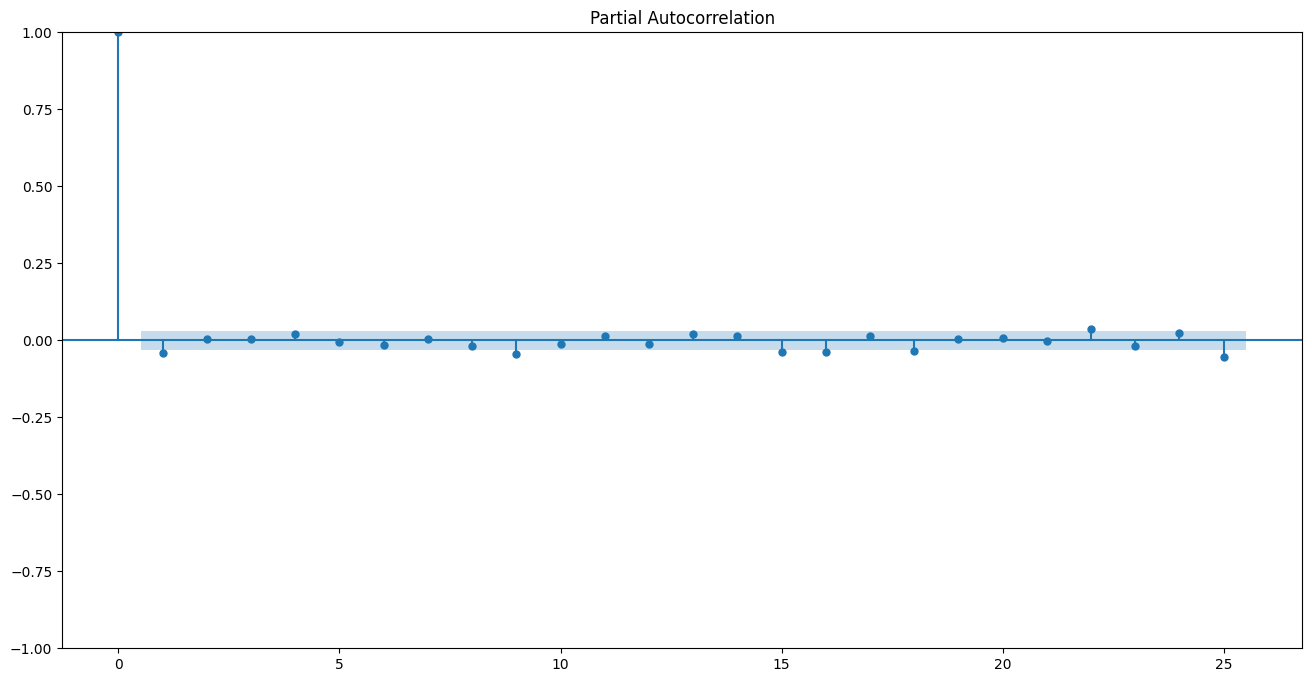

In [39]:
plt.rc("figure", figsize=(16,8))
fig = plot_pacf(df['log_rtns'].dropna().values.squeeze(), lags=25)
plt.show()

### Тяжёлые хвосты

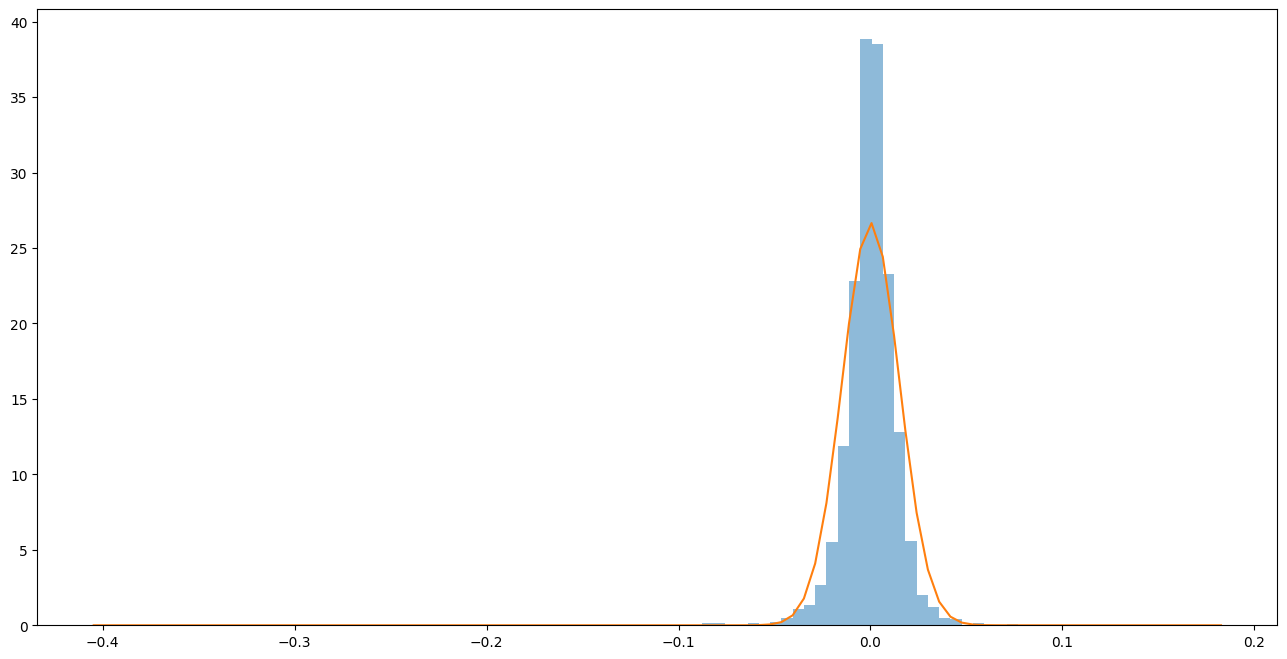

In [41]:
from scipy.stats import norm
import scipy

# Fit a normal distribution to the data:
mu, sigma = norm.fit(df['log_rtns'].dropna().values)

ig = plt.figure(figsize=(16,8))
_, bins, _ = plt.hist(df['log_rtns'].values, 100, density=1, alpha=0.5)

best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
plt.plot(bins, best_fit_line)


### QQ-график

Q-Q график, или график квантиль-квантиль, часто используют, чтобы оценить, могла ли выборка данных быть получена из некоторого теоретического распределения. Чаще всего такой график применяют для проверки, подчиняются ли данные нормальному распределению.

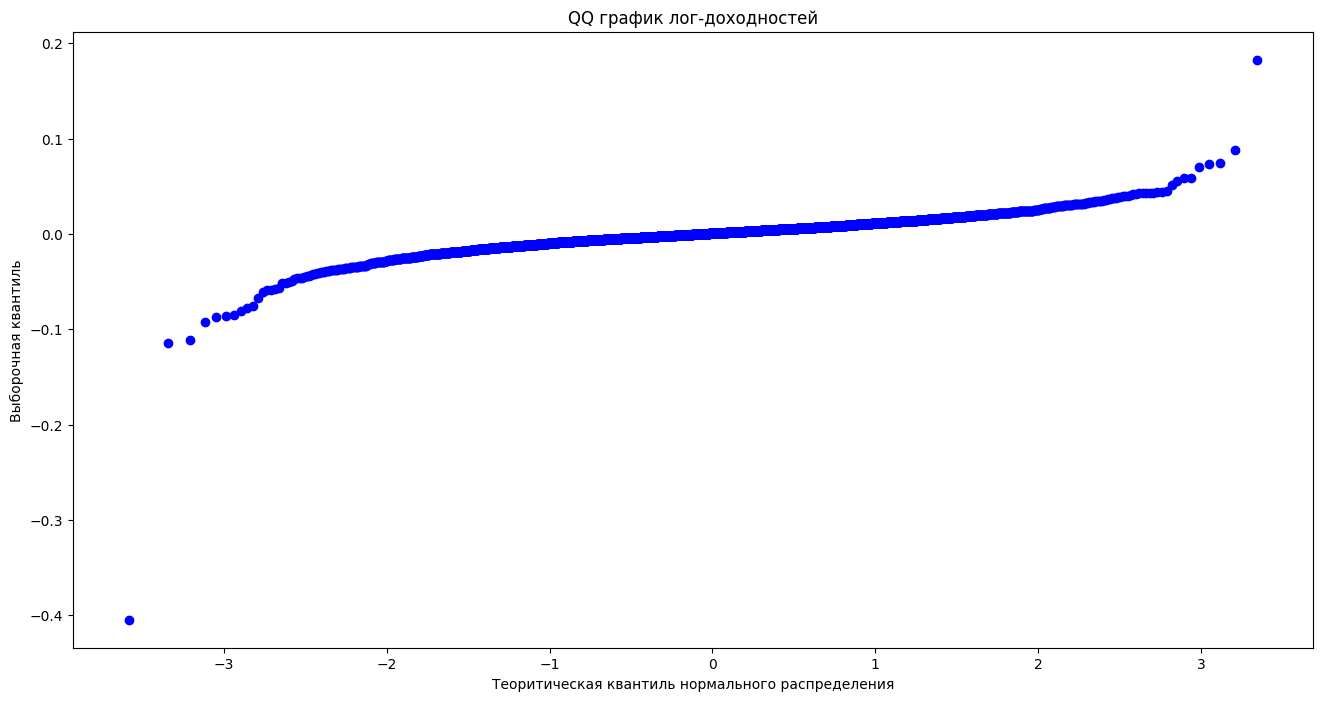

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generate QQ plot
stats.probplot(df['log_rtns'], dist="norm", plot=plt)

# Add plot title
plt.title("QQ график лог-доходностей")
plt.xlabel("Теоритическая квантиль нормального распределения")
plt.ylabel("Выборочная квантиль")

# Show the plot
plt.show()

**Оси на QQ-графике:**

* **Ось X**: Теоретические квантили (из нормального распределения, если `dist="norm"`).
* **Ось Y**: Выборочные квантили (из ваших фактических данных, `log_rtns`).

**Типичные формы на QQ-графике и их интерпретация:**

| **Наблюдение**                       | **Интерпретация**                                                                            |
| ------------------------------------ | -------------------------------------------------------------------------------------------- |
| **Точки лежат на прямой линии**      | Данные хорошо соответствуют нормальному распределению                                        |
| **Точки загибаются вверх на концах** | Признак **тяжелых хвостов** (положительный эксцесс), экстремальные значения встречаются чаще |
| **Точки загибаются вниз на концах**  | Признак **легких хвостов** (отрицательный эксцесс), экстремальные значения редки             |
| **S-образная форма**                 | Наличие **асимметрии**: распределение несимметрично                                          |
| - **Подъем слева**                   | **Левосторонняя асимметрия** (отрицательная skewness)                                        |
| - **Подъем справа**                  | **Правосторонняя асимметрия** (положительная skewness)                                       |
| **Хаотичное облако без формы**       | Данные не соответствуют выбранному теоретическому распределению                              |


### Почему важна стационарность

+ Стандартное предположение в анализе временных рядов - **стационарность**. Большинство методов неприменимы, если это условие не выполнено!
+ Ряд стационарен, если параметры процесса (обычно среднее и дисперсия) не меняются во времени и нет автокорреляции на всех лагах.

Let's look at two series A and B.

In [ ]:
mu, sigma = 0, 1 # mean and standard deviation
A = np.random.normal(mu, sigma, 100)

plt.figure(figsize=[14, 7])
plt.plot(A)
plt.title("A series (normally distributed)")
plt.show()

In [ ]:
B = []
mu, sigma = 0, 1 # mean and standard deviation

for i in range(100):
  x = np.random.normal(0.05 *i, sigma*(i/100), 1)
  B.append(x)


In [ ]:
plt.figure(figsize=[14, 7])
plt.plot(B)
plt.title("B series (linear trend with normally distributed errors)")
plt.show()

In [ ]:
mean = np.mean(B)
plt.figure(figsize=[14, 7])
plt.plot(B)
plt.axhline(y = mean, color = 'r', linestyle = '-')
plt.show()


## Как проверить стационарность временного ряда?

1. Визуально.
2. Скользящее среднее и дисперсия.
3. Формальные тесты, например ADF.


Исправленный и переведённый вариант:

Если ряд ( $x_t$ ) не является стационарным, можно вычислить его разности

$$ z_t = x_t - x_{t-1} $$

и проверить уже этот новый ряд на стационарность. Именно это мы фактически делаем, когда рассчитываем логарифмические доходности.

## Тест ADF (Дики - Фуллера)

Нулевая гипотеза теста Дики-Фуллера (ADF) состоит в том, что временной ряд нестационарен, то есть содержит единичный корень. Тест ADF проверяет, есть ли в ряде устойчивая тенденция или случайное блуждание. Если ряд нестационарен, его среднее и дисперсия меняются со временем. Тогда стандартные методы анализа (регрессии, корреляции) могут давать ложные результаты.

In [44]:
from statsmodels.tsa.stattools import adfuller

In [46]:
def adfuller_summary(X):
  result = adfuller(X)
  print('ADF Statistic: %f' % result[0])
  print('p-value: %f' % result[1])
  print('Critical Values:')
  for key, value in result[4].items():
	  print('\t%s: %.3f' % (key, value))
  return result

adfuller_summary(df['log_rtns'].dropna())



ADF Statistic: -12.876035
p-value: 0.000000
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567


(np.float64(-12.876035232536264),
 np.float64(4.7672871090978644e-24),
 25,
 4008,
 {'1%': np.float64(-3.431982608051027),
  '5%': np.float64(-2.8622613969260846),
  '10%': np.float64(-2.5671540071976806)},
 np.float64(-22290.69681644224))

In [ ]:
result = adfuller(df['log_rtns'])
# Check stationarity conclusion
if result[1] <= 0.05:
    print("\nThe series is stationary (reject the null hypothesis).")
else:
    print("\nThe series is NOT stationary (fail to reject the null hypothesis).")


Как интерпретировать результат теста:

- Если p-value меньше выбранного уровня значимости (например, 0.05), мы отвергаем H₀ → ряд считается стационарным
- Если p-value больше 0.05, у нас недостаточно оснований отвергнуть H₀ → ряд может быть нестационарным

ВАЖНО: «не удалось отвергнуть H₀» не означает, что ряд точно нестационарен. Это означает, что данных недостаточно, чтобы доказать стационарность.

В финансах цены активов обычно нестационарны, а вот их лог-доходности чаще всего стационарны, поэтому анализ обычно проводят именно на доходностях.

In [47]:
result = adfuller_summary(df['close'])

# Check stationarity conclusion
if result[1] <= 0.05:
    print("\nThe series is stationary (reject the null hypothesis).")
else:
    print("\nThe series is NOT stationary (fail to reject the null hypothesis).")



ADF Statistic: -1.681494
p-value: 0.440672
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567

The series is NOT stationary (fail to reject the null hypothesis).


In [ ]:
result

## Тест KPSS

Нулевая гипотеза теста KPSS утверждает, что временной ряд стационарен (вокруг постоянного среднего или детерминированного тренда, в зависимости от спецификации теста).

In [49]:
from statsmodels.tsa.stattools import kpss

# Perform the KPSS test
kpss_stat, p_value, lags, critical_values = kpss(df['log_rtns'].dropna(), regression='c')  # 'c' for constant trend, use this when you suspect that the series is stationary around a constant mean

# Print KPSS test results
print("KPSS Test Results:")
print(f"KPSS Statistic: {kpss_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Lags: {lags}")
print("Critical Values:")
for key, value in critical_values.items():
    print(f"   {key}: {value:.4f}")

# Conclusion
if p_value <= 0.05:
    print("\nThe series is NOT stationary (reject the null hypothesis).")
else:
    print("\nThe series is stationary (fail to reject the null hypothesis).")

KPSS Test Results:
KPSS Statistic: 0.0435
P-value: 0.1000
Lags: 5
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390

The series is stationary (fail to reject the null hypothesis).


C:\Users\m_salihov\AppData\Local\Temp\ipykernel_8148\2631200623.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, lags, critical_values = kpss(df['log_rtns'].dropna(), regression='c')  # 'c' for constant trend, use this when you suspect that the series is stationary around a constant mean


Формулировки гипотез в тесте KPSS:

- H₀ (нулевая гипотеза): ряд стационарен
- H₁ (альтернативная гипотеза): ряд нестационарен (имеет единичный корень или тренд-нестационарность)

Как интерпретировать результат:

- Если p-value меньше уровня значимости (например, 0.05), мы отвергаем H₀ → есть основания считать ряд нестационарным
- Если p-value больше 0.05, нет оснований отвергать H₀ → ряд можно считать стационарным

Почему часто используют вместе ADF и KPSS:

- ADF проверяет гипотезу «ряд нестационарен»
- KPSS проверяет гипотезу «ряд стационарен»

Если ADF отвергает нестационарность, а KPSS не отвергает стационарность, вывод о стационарности более надежен. Если оба теста указывают на нестационарность, это сильный сигнал наличия единичного корня.

## Задание 3

1. Посчитайте статистику ADF для цен вашего тикера. Как можно интерпретировать?
2. Посчитайте статистику ADF для лог-доходностей вашего тикера. Как можно интерпретировать?
3. Посчитайте статистику KPSS для лог-доходностей вашего тикера. Как можно интерпретировать?
4. Какие выводы о стационарности лог-доходностей можно сделать на основе обоих тестов? 

## Как проверить качество модели?

+ Проверка структуры остатков (ACF, PACF, тесты на автокорреляцию и т.д.)
+ Метрики на обучающей выборке, например $R^2$
+ Информационные критерии (AIC, BIC). Тоже in-sample!
+ Ошибки вне выборки

Базовый подход к построению финансовых моделей заключается в том, чтобы модель давала остатки без автокорреляции.

Если $y_t$ - фактическое значение ряда в момент времени $ t $, а $ \hat{y}_t $ - значение, предсказанное моделью, то остаток определяется как

$$ x_t = y_t - \hat{y}_t $$

Анализ остатков позволяет понять, хорошо ли модель описывает данные.


Хорошая модель должна «забирать» всю систематическую структуру из данных. Тогда в остатках остаётся только случайный шум.

**Что проверяют в остатках:**

1. **Отсутствие автокорреляции**
   Остатки не должны зависеть от своих прошлых значений. Если автокорреляция есть, значит модель не учла часть динамики ряда.

2. **Нулевое среднее**
   Среднее значение остатков должно быть близко к нулю. Иначе модель систематически переоценивает или недооценивает значения.

3. **Постоянная дисперсия (гомоскедастичность)**
   Разброс остатков не должен сильно меняться со временем. В финансах это условие часто нарушается, и тогда применяют модели типа ARCH или GARCH.

4. **Отсутствие структуры**
   На графике остатков не должно быть трендов, циклов или других закономерностей.

Если в остатках остаётся структура, значит модель неполная и её можно улучшить, добавив лаги, факторы или изменив спецификацию.


Анализ остатков - это ключевой шаг проверки адекватности модели, особенно в задачах прогнозирования финансовых временных рядов.




## Типы финансовых рядов

### Белый шум

Предположим, что у нас есть ряд случайных величин ${w_t: t = 1, \ldots, n}$.

Если элементы (w_t) являются **независимыми и одинаково распределёнными** (i.i.d.) и выполняются следующие условия:

1. **Математическое ожидание равно нулю**
   $\mathbb{E}[w_t] = 0$

2. **Дисперсия постоянна**
   $\mathrm{Var}(w_t) = \sigma^2 = \text{const}$

3. **Отсутствует автокорреляция**
   $\mathrm{Corr}(w_i, w_j) = 0$ для всех $i \neq j$

то процесс (w_t) называется **белым шумом**.


#### Что это означает на практике

Белый шум полностью случаен и не содержит предсказуемой структуры. Его прошлые значения не дают информации о будущих.

Поэтому в моделировании временных рядов цель состоит в том, чтобы после построения модели в остатках не осталось ничего, кроме белого шума. Это означает, что модель извлекла весь систематический сигнал из данных.

Если остатки модели ведут себя как белый шум, модель считается адекватной.



#### Связь с моделями

Обычно предполагается, что наблюдаемый ряд можно представить как сумму сигнала и случайного шума:

$$ x_t = \text{Сигнал} + \text{Белый шум} $$

Задача модели - описать **сигнал**.
То, что остаётся после вычитания прогноза из фактических значений, - это шум:

$$ \text{остаток}_t = x_t - \hat{x}_t $$

Если эти остатки похожи на белый шум, значит модель успешно объяснила структуру данных.

#### Важно для понимания

На практике «идеальный» белый шум встречается редко. Часто в остатках остаётся:

* автокорреляция → модель не учла динамику
* изменяющаяся дисперсия → требуется модель волатильности (например, GARCH)
* асимметрия или тяжёлые хвосты → финансовые данные часто не нормальны

Поэтому проверка остатков на «похожесть» на белый шум - ключевой этап диагностики модели.

### Случайное блуждание


**Случайное блуждание (Random Walk, RW)** - это модель временного ряда, в которой текущее значение равно предыдущему значению плюс случайный шум (белый шум):

$$ 
x_t = x_{t-1} + w_t,
$$

где $w_t$ - белый шум с нулевым средним и постоянной дисперсией $\sigma^2$.

#### Развернутая форма

Последовательно подставляя предыдущие значения, получаем:

$$
x_t = x_{t-1} + w_t = x_{t-2} + w_{t-1} + w_t = \dots = x_0 + \sum_{i=1}^{t} w_i
$$

То есть случайное блуждание - это **накопленная сумма белого шума**.

#### Математическое ожидание случайного блуждания

$$
\mathbb{E}(x_t) = \mathbb{E}\left(x_0 + \sum_{i=1}^{t} w_i\right)
= x_0 + \sum_{i=1}^{t} \mathbb{E}(w_i)
= x_0
$$

Среднее значение не меняется со временем.


### Дисперсия случайного блуждания 

$$ \mathrm{Var}(x_t) = \mathrm{Var}\left(\sum_{i=1}^{t} w_i\right)
= \sum_{i=1}^{t} \mathrm{Var}(w_i)
= t\sigma^2
$$ 

Дисперсия RW **растет линейно со временем**.


### Почему случайное блуждание нестационарно?

Стационарный ряд должен иметь:

1. Постоянное среднее
2. Постоянную дисперсию
3. Зависимость между значениями только от лага, а не от времени

У случайного блуждания нарушается второе условие:

$$ 
\mathrm{Var}(x_t) = t\sigma^2 \quad \Rightarrow \quad \text{дисперсия растет со временем}
$$ 

Следовательно, распределение ряда меняется со временем, и процесс **не является стационарным**.


Каждый новый случайный шок накапливается и навсегда остается в ряде. Поэтому:

* уровень ряда «блуждает»
* нет возврата к среднему
* долгосрочный прогноз равен последнему наблюдению


#### Связь с финансами

Цены финансовых активов часто моделируются как случайное блуждание, а вот их изменения (разности или лог-доходности)

$$  r_t = x_t - x_{t-1} = w_t $$

уже являются белым шумом и ближе к стационарному процессу.



**Кратко:**
Случайное блуждание нестационарно, потому что его неопределенность (дисперсия) растет со временем.




In [50]:
steps = np.random.standard_normal(1000)
steps[0] = 0
random_walk = np.cumsum(steps)

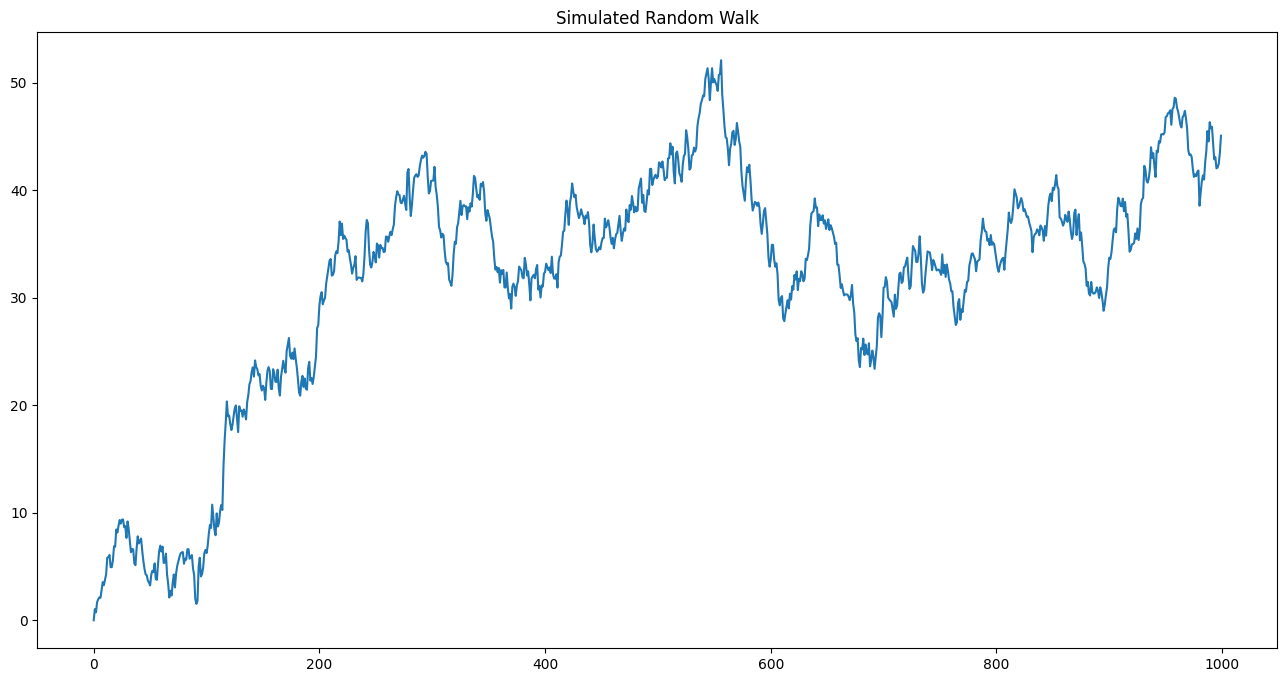

In [51]:
plt.figure(figsize=[16, 8 ])
plt.plot(random_walk)
plt.title("Simulated Random Walk")
plt.show()

In [52]:
adfuller_summary(random_walk)

ADF Statistic: -2.507006
p-value: 0.113779
Critical Values:
	1%: -3.437
	5%: -2.864
	10%: -2.568


(np.float64(-2.507005570142198),
 np.float64(0.11377908547737003),
 1,
 998,
 {'1%': np.float64(-3.4369193380671),
  '5%': np.float64(-2.864440383452517),
  '10%': np.float64(-2.56831430323573)},
 np.float64(2811.396140613075))

ВОПРС. Какой вывод можно сделать? 

## AR-модель

### Авторегрессионные модели (AR)

**AR-модель (autoregressive model)** - это модель временного ряда, в которой текущее значение объясняется его прошлыми значениями (лагами).

**AR(p)** означает, что используется (p) лагов ряда, то есть выполняется регрессия текущего значения на (p) предыдущих наблюдений.

Самая простая версия - **AR(1)**, где используется только один лаг.


### Модель AR(1)

$$
x_t = b_0 + b_1 x_{t-1} + \varepsilon_t
$$

где
$b_0$ - константа (сдвиг среднего),
$b_1$ - коэффициент авторегрессии,
$\varepsilon_t$ - белый шум (случайная ошибка с нулевым средним и постоянной дисперсией).


### Модель AR(p)

$$
x_t = b_0 + b_1 x_{t-1} + b_2 x_{t-2} + \dots + b_p x_{t-p} + \varepsilon_t
$$

То есть текущее значение зависит от (p) предыдущих значений и случайной компоненты.


### Интуиция

AR-модель предполагает, что ряд обладает **памятью**: прошлые значения содержат информацию о будущем.

Например:

* если (b_1 > 0), то высокие значения в прошлом увеличивают вероятность высоких значений сейчас
* если (b_1 < 0), наблюдается возврат к среднему и колебательное поведение


### Важное условие стационарности

AR-модель является стационарной только если коэффициенты удовлетворяют определённым ограничениям.

Для AR(1):

$$
|b_1| < 1
$$

Если (|b_1| \ge 1), процесс становится нестационарным (например, при (b_1 = 1) получаем случайное блуждание).

### Где используется

AR-модели лежат в основе более сложных моделей временных рядов:

* ARMA
* ARIMA
* GARCH (для волатильности)

AR-модели широко применяются в экономике и финансах для моделирования временных рядов.



### Симуляция AR(1)

Симулируем AR(1) c  $b_1$ = 0.7



In [53]:
ar1 = w = np.random.standard_normal(1000)

for t in range(2,1000):
  ar1[t] = 0.7 * ar1[t-1] + w[t]

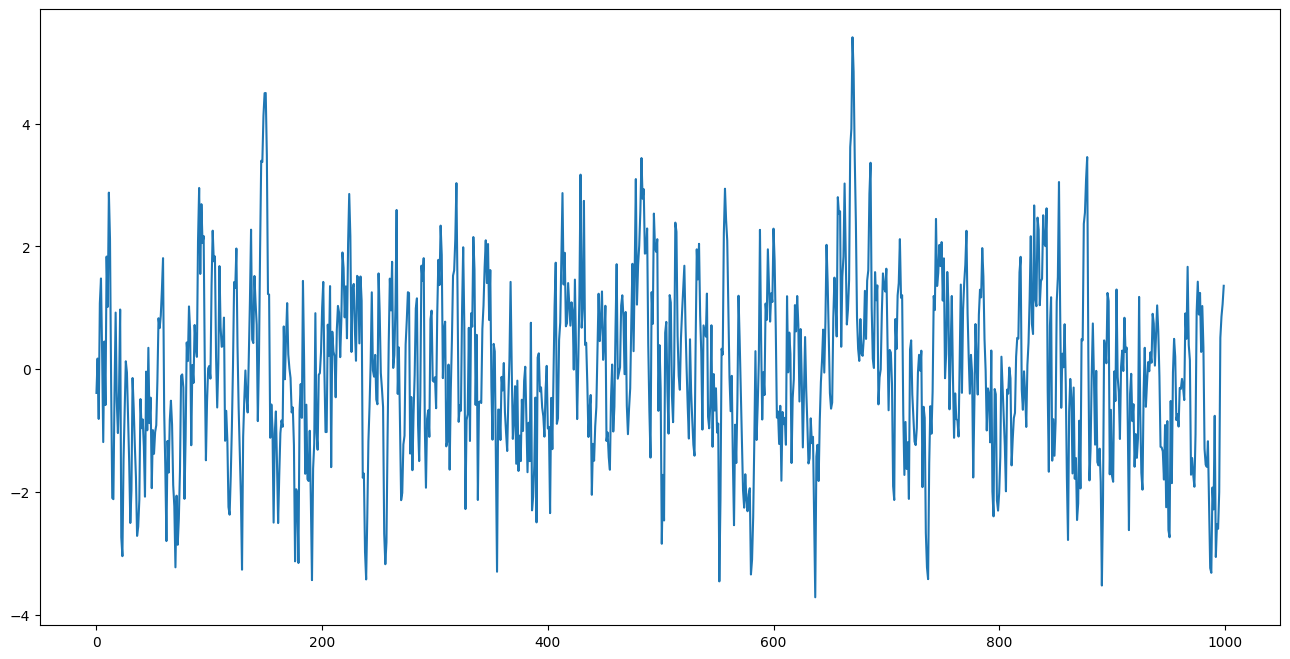

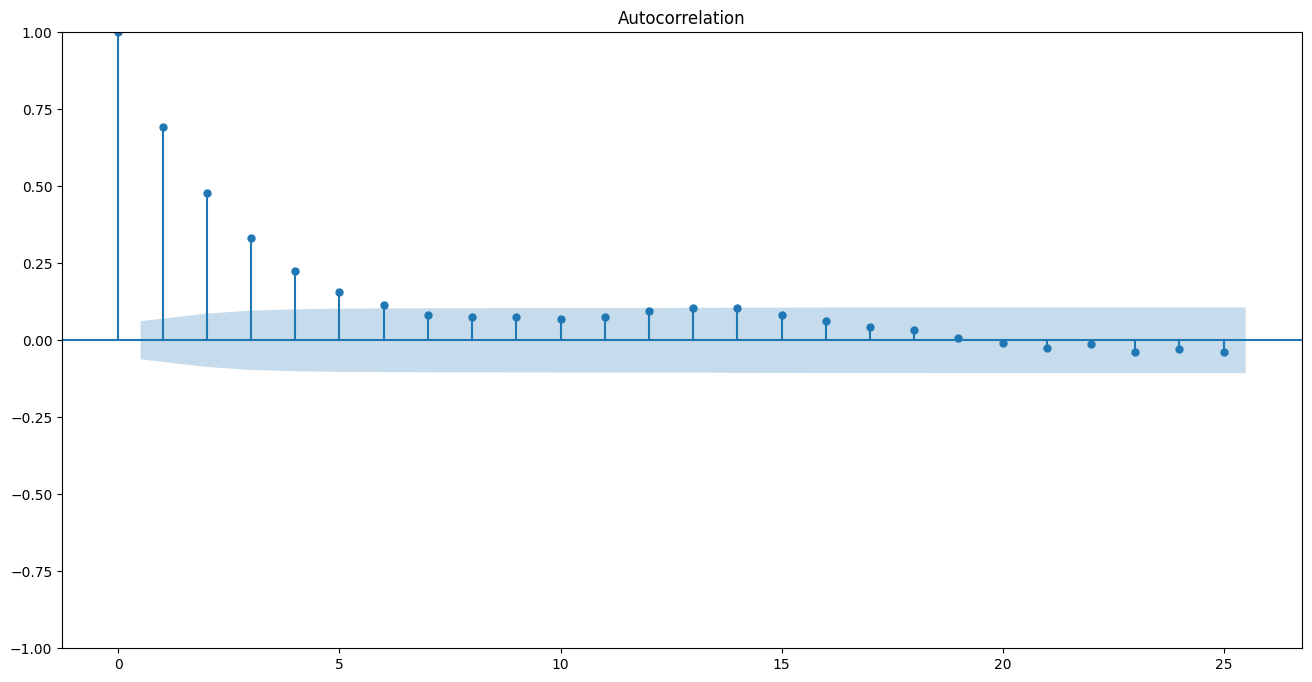

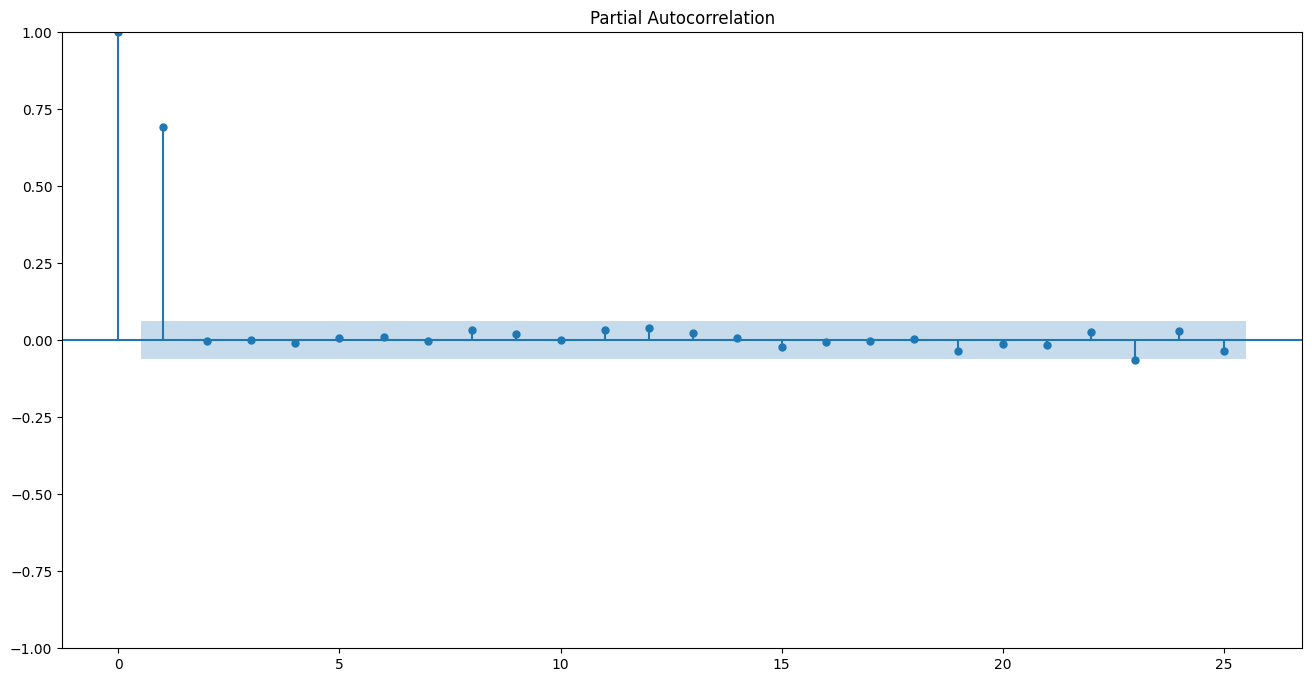

In [54]:
plt.plot(ar1)
fig = plot_acf(ar1, lags = 25)
fig = plot_pacf(ar1, lags = 25)

AR(p):

- ACF убывает постепенно
- PACF резко обрывается на лаге p

**PACF показывает порядок AR-модели.**

### AR(2) модель для доходностей IMOEX

In [56]:
#df = df.asfreq(pd.infer_freq(df.index))  # Infer and assign frequency
print(df.index.freq)  # Check assigned frequency

<Day>


In [ ]:
df['log_rtns']


In [57]:
model = ARIMA(df['log_rtns'].dropna(), order=(1,0,0)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               log_rtns   No. Observations:                 4034
Model:                 ARIMA(1, 0, 0)   Log Likelihood               11230.648
Date:                Tue, 03 Feb 2026   AIC                         -22455.296
Time:                        20:03:40   BIC                         -22436.388
Sample:                    01-12-2010   HQIC                        -22448.596
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.613      0.540      -0.000       0.001
ar.L1         -0.0399      0.003    -11.698      0.000      -0.047      -0.033
sigma2         0.0002   6.94e-07    322.298      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           3305818.52
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.74   Skew:                            -5.10
Prob(H) (two-sided):                  0.00   Kurtosis:                       142.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [59]:
model = ARIMA(df['log_rtns'].dropna(), order=(2,0,0)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               log_rtns   No. Observations:                 4034
Model:                 ARIMA(2, 0, 0)   Log Likelihood               11230.713
Date:                Tue, 03 Feb 2026   AIC                         -22453.426
Time:                        20:04:02   BIC                         -22428.216
Sample:                    01-12-2010   HQIC                        -22444.494
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.604      0.546      -0.000       0.001
ar.L1         -0.0396      0.003    -11.630      0.000      -0.046      -0.033
ar.L2          0.0057      0.008      0.736      0.462      -0.009       0.021
sigma2         0.0002   1.11e-06    200.678      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           3267409.37
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.74   Skew:                            -5.07
Prob(H) (two-sided):                  0.00   Kurtosis:                       142.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

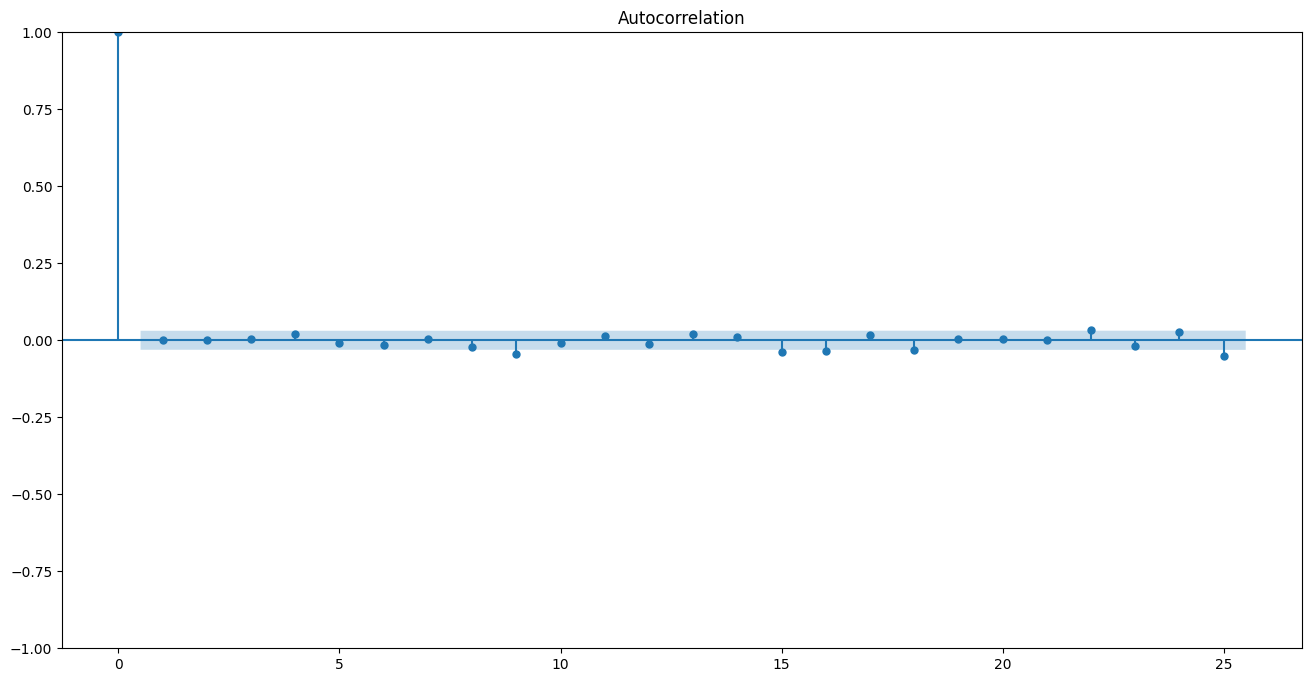

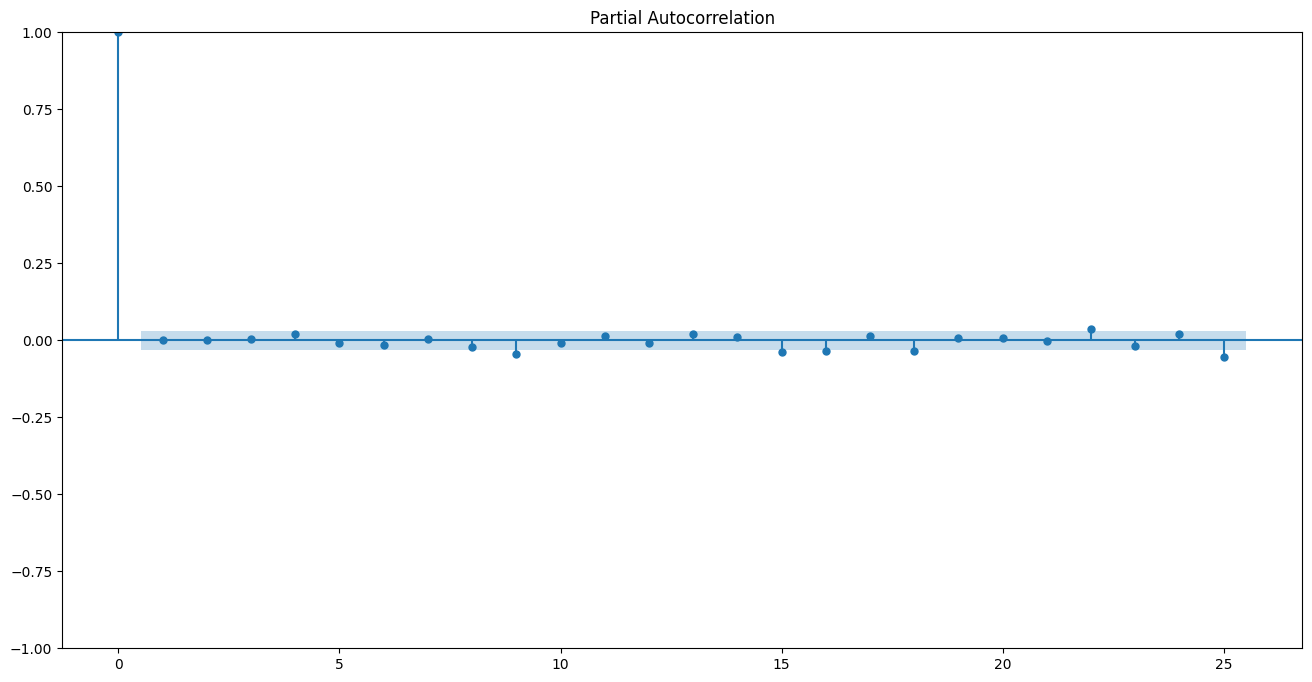

In [60]:
resid = model.resid
fig = plot_acf(resid, lags = 25)
fig = plot_pacf(resid, lags = 25)

## ЗАДАНИЕ 4 

1. Постройте AR модель для вашего тикера. 
2. Какой порядок модели? 
3. Проанализируйте остатки. Какие выводы о качестве модели можно сделать? 

Какие выводы можно сделать из анализа остатков AR(2)?

## Тест Льюнга - Бокса

**Тест Льюнга - Бокса** (Ljung–Box test, назван в честь Греты М. Льюнг и Джорджа Бокса) - это статистический тест, который проверяет, отличаются ли автокорреляции временного ряда от нуля **совместно по группе лагов**.

В отличие от проверки значимости автокорреляции на каждом лаге по отдельности, этот тест оценивает **общую случайность (отсутствие автокорреляции)** сразу по нескольким лагам.

Тест также называют **Ljung–Box Q-тестом**. Он тесно связан с тестом Бокса - Пирса.

**Тест Бокса - Пирса** является более простой (и менее точной при малых выборках) версией теста Льюнга - Бокса.


### Формулировка гипотез

* **H₀ (нулевая гипотеза):** автокорреляции до лага (h) равны нулю → ряд ведёт себя как белый шум
* **H₁ (альтернативная гипотеза):** по крайней мере одна автокорреляция отлична от нуля → в ряде есть зависимость



### Статистика теста

$$
Q^* = T(T+2)\sum_{k=1}^{h} \frac{r_k^2}{T-k}
$$

где
$T$ - длина временного ряда
$r_k$ - выборочная автокорреляция на лаге (k)
$h$ - число лагов, включённых в тест (задаётся исследователем)


### Интерпретация

* **Большие значения (Q^*)** указывают на наличие автокорреляции в ряде
* Если **p-value < 0.05**, нулевая гипотеза отвергается → есть статистически значимая автокорреляция
* Если **p-value ≥ 0.05**, нет оснований отвергать нулевую гипотезу → автокорреляция статистически не обнаружена

Важно: «не удалось обнаружить автокорреляцию» не означает, что её точно нет - просто данных недостаточно, чтобы это доказать.


### Где используется

Тест Льюнга - Бокса широко применяется:

* для проверки остатков моделей ARIMA
* для диагностики GARCH-моделей
* для проверки, является ли ряд белым шумом

Если остатки модели проходят тест (то есть не показывают автокорреляции), это признак того, что модель адекватно описала динамику ряда.

**Кратко:**
Тест Льюнга - Бокса проверяет, осталась ли в ряде или в остатках модели автокорреляция.




In [61]:
test = sm.stats.diagnostic.acorr_ljungbox(resid, lags=[10], boxpierce=True)

In [65]:
test

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
10,13.10849,0.217669,13.076382,0.219433


In [68]:
test

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
10,13.10849,0.217669,13.076382,0.219433


In [66]:
result = test['lb_pvalue'].iloc[0]
if result <= 0.05:
    print("\nThere is evidence of significant autocorrelation in the data (reject the null).")
else:
    print("\nThe data (or residuals) show no significant autocorrelation (fail to reject the null).")



The data (or residuals) show no significant autocorrelation (fail to reject the null).


In [ ]:
?sm.stats.acorr_ljungbox


## Прогнозирование с ARIMA

In [ ]:
# Train-Test Split
log_rtns = df['log_rtns'].dropna()
train = log_rtns[log_rtns.index < '2024-11-01']  # Training data before nov 2024
test = log_rtns[log_rtns.index > '2024-11-01']  # Test data after nov 2024
test_dates = test.index


In [ ]:
model = ARIMA(train, order=(2,0,2)).fit()
model.summary()

In [ ]:
forecast = model.forecast(steps=len(test))

In [ ]:
forecast

In [ ]:
forecasts = []
rolling_data = train.copy()  # Copy of training data to simulate rolling updates


In [ ]:
test_dates

In [ ]:
test

In [ ]:
for date in test_dates:
    # Fit the ARMA(2,1) model on rolling data
    print(date)
    model = ARIMA(rolling_data, order=(2, 0, 2))
    fitted_model = model.fit()

    # Forecast the next day
    forecast = fitted_model.forecast(steps=1).iloc[0]
    forecasts.append(forecast)

    # Append the actual data to the rolling dataset for future forecasts
    rolling_data.loc[date] = test.loc[date]  # Include actual value from test

In [ ]:
forecast_df = pd.DataFrame({'forecast': forecasts, 'actual': test.values}, index=test_dates)
forecast_df

In [ ]:
# @title Forecast vs Actual

from matplotlib import pyplot as plt
forecast_df.plot(kind='scatter', x='Forecast', y='Actual', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xlim([-0.02, 0.02])  # Adjust as needed
plt.ylim([-0.02, 0.02])  # Adjust as needed

## Модели скользящего среднего (MA)

### MA(1) модель в Excel (пример)

+ MA-модели похожи на AR, но используют линейную комбинацию прошлых **ошибок**, а не прошлых значений.
+ MA «видит» шоки белого шума напрямую. AR «видит» их косвенно через регрессию на прошлые значения.
+ MA(q) учитывает последние q шоков; AR(p) - все предыдущие шоки с затухающим весом.


If $x_t$ is $MA(q)$ model then

$$ x_t = \beta_0 + \beta_1 \epsilon_{t-1} + \ldots + \beta_q \epsilon_{t-q} + \epsilon_t $$

where ${w_t}$ is white noise with $E(w_t)=0$ and variance $\sigma^2$.



### Симуляция MA(1)

In [ ]:
def tsplot(y, lags=None, figsize=(10, 8), style='default'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        ts_ax.set_title('Time Series Plots')
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5)
        plt.tight_layout()
    return

# Simulate an MA(1) process
n = int(1000)

# set the AR(p) alphas equal to 0
alphas = np.array([0.])
betas = np.array([-0.6])

# add zero-lag and negate alphas
ar = np.r_[1, alphas] # concatenate
ma = np.r_[1, betas]

ma1 = smt.arma_generate_sample(ar=ar, ma=ma, nsample=n)
tsplot(ma1, lags=30)

In [ ]:
model = ARIMA(ma1, order=(0,0,1)).fit()
model.summary()

### MA(2) модель для доходностей IMOEX

In [ ]:
model = ARIMA(df['log_rtns'], order=(0,0,2)).fit()
model.summary()

In [ ]:
tsplot(resid, lags = 25)

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

test = acorr_ljungbox(resid, lags=[10], boxpierce=True)
print(test)

**Различия между моделями AR и MA**

| **Аспект**            | **AR-модель**                                         | **MA-модель**                                                   |
| --------------------- | ----------------------------------------------------- | --------------------------------------------------------------- |
| **Зависимость**       | Зависит от прошлых значений самого ряда               | Зависит от прошлых ошибок (шоков)                               |
| **Структура**         | Регрессия на лаги наблюдаемых значений                | Регрессия на лаги случайных ошибок                              |
| **Когда применяется** | Описывает устойчивость и инерцию процесса             | Описывает краткосрочные шоки и случайные колебания              |
| **Порядок лагов**     | AR(p): число прошлых значений ряда                    | MA(q): число прошлых ошибок                                     |
| **Стационарность**    | Требует стационарности ряда (в стандартной форме)     | Применяется к стационарным процессам                     |
| **Интерпретация**     | Текущее значение объясняется прошлым поведением ряда  | Текущее значение объясняется накопленным эффектом прошлых шоков |
| **Пример в финансах** | Автокорреляция доходностей, инерция рыночных движений | Реакция на новости и неожиданные рыночные события               |

---

### Важно понимать

* **AR-модель** описывает внутреннюю динамику ряда, его «память»
* **MA-модель** описывает влияние прошлых случайных возмущений

На практике часто используются комбинированные модели **ARMA** и **ARIMA**, которые учитывают оба эффекта.

## Проверка и выбор модели

### Информационные критерии (AIC и BIC)

Информационные критерии используются для выбора наилучшей модели из нескольких альтернатив. Они позволяют сравнивать модели по принципу компромисса между качеством подгонки и сложностью модели.

Наиболее распространены:

* **критерий Акаике (AIC)**
* **байесовский информационный критерий (BIC)**


#### Общая идея

Любая более сложная модель почти всегда лучше подгоняется под данные. Но слишком сложные модели переобучаются и хуже работают на новых данных.

Информационные критерии реализуют принцип «бритвы Оккама»:
мы стремимся выбрать **как можно более простую модель**, которая при этом **достаточно хорошо описывает данные**.

Во всех случаях предпочтение отдаётся модели с **меньшим значением критерия**.

#### Критерий Акаике (AIC)

$$
AIC = -2 \log(L) + 2k
$$

где
$L$) — максимальное значение функции правдоподобия модели
$k$ — число оценённых параметров в модели

Первый член отражает качество подгонки (чем выше правдоподобие, тем лучше), второй — штраф за сложность.

#### Байесовский информационный критерий (BIC)

$$
BIC = -2 \log(L) + k \log(n)
$$

где
$n$ — число наблюдений
$k$ — число параметров

BIC накладывает **более сильный штраф за сложность**, чем AIC, особенно при больших выборках.

#### Важные замечания

* Абсолютные значения AIC и BIC **не имеют самостоятельного смысла**
* Они используются **только для сравнения моделей между собой**
* Значения информационных критериев **нельзя сравнивать между разными временными рядами**
* Модель с минимальным AIC или BIC считается предпочтительной среди рассматриваемых вариантов, но это не гарантирует, что она идеальна

#### Коротко

AIC и BIC помогают выбрать модель, которая:

* хорошо описывает данные
* не содержит лишних параметров

В финансах чаще ориентируются на AIC, но выбор зависит от цели. Универсального ответа нет. Лучший подход - проверять оба, а затем сравнивать вневыборочное качество прогноза



### Ошибки вне выборки

Ошибка (или остаток) - это разница между фактическим значением и значением, предсказанным моделью. Здесь слово «ошибка» не означает промах, а обозначает часть ряда, которую модель не смогла объяснить.

$$
e_t = y_t - \hat{y}_t
$$

Метрика ошибки — это числовая характеристика остатков.


#### Основные метрики прогностической ошибки

**Средняя абсолютная ошибка (MAE)**
$$
MAE = \text{mean}(|e_t|)
$$
Показывает средний размер ошибки в тех же единицах, что и исходные данные.

**Корень из средней квадратичной ошибки (RMSE)**
$$
RMSE = \sqrt{\text{mean}(e_t^2)}
$$
Сильнее штрафует большие ошибки, чем MAE.

**Средняя абсолютная процентная ошибка (MAPE)**
$$
MAPE = \text{mean}(|p_t|)
$$
где
$$
p_t = 100 \cdot \frac{e_t}{y_t}
$$

MAPE показывает ошибку в процентах от фактического значения.

#### Разделение данных

* **Обучающая выборка** — используется для оценки параметров модели
* **Тестовая выборка** — используется для проверки качества прогноза

Для акций деление выборки отличается от классического ML. Главное правило: нельзя перемешивать данные во времени. **Будущее не должно попадать в обучение**.

Обучаемся на прошлом → тестируем на будущем.


### Ошибки вне выборки (out-of-sample)

Ошибки вне выборки — это ошибки, рассчитанные на тестовой выборке, то есть на данных, которые **не использовались** при построении модели.

Именно эти ошибки показывают, насколько модель способна прогнозировать новые данные, а не просто подгоняться под уже известные.

#### Важно помнить

* Низкая ошибка на обучающей выборке не гарантирует хорошего прогноза
* Главный критерий качества модели — её поведение **вне выборки**






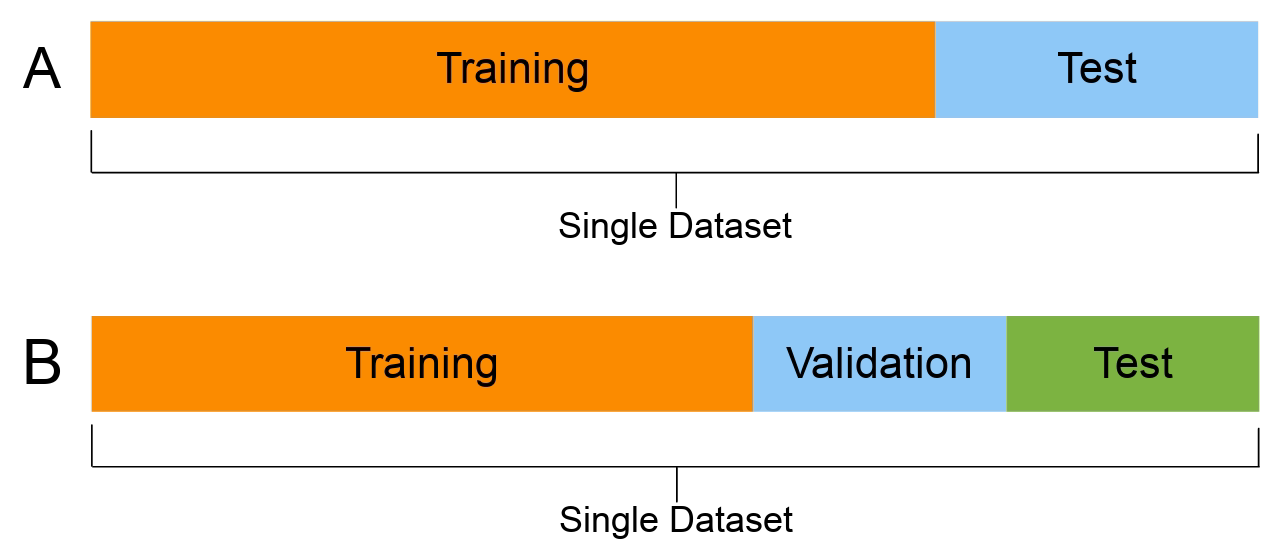


### ARMA-модели

Если объединить авторегрессионную (AR) и модель скользящего среднего (MA), получаем модель **ARMA** (Autoregressive Moving Average).

Если процесс (x_t) имеет структуру ARMA(p, q), то его можно записать так:

$$
x_t = \alpha_1 x_{t-1} + \alpha_2 x_{t-2} + \dots + \alpha_p x_{t-p}
+ \beta_1 w_{t-1} + \beta_2 w_{t-2} + \dots + \beta_q w_{t-q}
+ w_t
$$

где
$x_{t-1}, \dots, x_{t-p}$ — прошлые значения ряда (AR-часть),
$w_t$ — белый шум,
$w_{t-1}, \dots, w_{t-q}$ — прошлые случайные шоки (MA-часть),
$\alpha_i$ и $\beta_j$ — параметры модели.

#### Интуиция

ARMA-модель описывает текущую динамику как сочетание:

* **внутренней инерции** ряда (зависимость от собственных прошлых значений),
* **влияния прошлых случайных шоков**.

Это делает модель более гибкой, чем чистая AR или чистая MA.

#### Когда применяется

ARMA-модели используются для стационарных временных рядов. Если ряд нестационарен, обычно сначала берут разности, а затем применяют модель ARMA — в этом случае модель называется **ARIMA**.


ARMA-процесс можно смоделировать с помощью программного кода (например, в Python или R), задав значения параметров $\alpha_i$ и $\beta_j$ и сгенерировав белый шум.




In [ ]:
# ARMA(1,1)
alphas = np.array([0.3])
betas = np.array([-0.6])
n = 100

# add zero-lag and negate alphas
ar = np.r_[1, alphas] # concatenate
ma = np.r_[1, betas]

arma11 = smt.arma_generate_sample(ar=ar, ma=ma, nsample=n)
plt.plot(arma11, label='ARMA(1,1) process')


In [ ]:
model = ARIMA(df['log_rtns'], order=(2,0,2)).fit()
model.summary()

In [ ]:
order_list = np.arange(0,5)
results = []
for digit in order_list:
    model = ARIMA(df['log_rtns'], order=(0,0,digit)).fit()
    results.append(model)

In [ ]:
for model in results:
  print(model.summary())

In [ ]:
aic_ma = []
for elem in results:
  aic_ma.append(elem.aic)

In [ ]:
print('AIC for models', *zip(aic_ma,order_list))

In [ ]:
plt.plot(order_list, aic_ma)
plt.xlabel('Order of MA')
plt.ylabel('AIC')

In [ ]:
bic_ma = []
for elem in results:
  bic_ma.append(elem.bic)

In [ ]:
print('BIC for models', *zip(bic_ma,order_list))

In [ ]:
plt.plot(order_list,bic_ma)
plt.xlabel('Order of MA')
plt.ylabel('BIC')

### Выбор порядка ARMA

In [ ]:
ar_list = np.arange(0,5)
ma_list = np.arange(0,5)

results = []

for ar_order in ar_list:
  for ma_order in ma_list:
    model = ARIMA(df['log_rtns'], order=(ar_order,0, ma_order)).fit()
    results.append(model)

In [ ]:
model = ARIMA(df['log_rtns'], order=(5,0,5)).fit()
model.summary()

### Ошибка «The computed initial AR coefficients are not stationary …»

Такое сообщение иногда появляется при оценке модели ARIMA или ARMA. Оно означает, что на этапе начальной инициализации алгоритм получил такие значения авторегрессионных коэффициентов, при которых процесс оказывается **нестационарным** (например, корни характеристического полинома лежат внутри единичного круга).

Это не обязательно означает, что сама модель неверна, но указывает на проблему с численной оптимизацией или спецификацией.

#### Что можно сделать

**1. Изменить метод оценки (`method` в `ARIMA.fit`)**

Разные алгоритмы оптимизации по-разному ищут максимум функции правдоподобия. Иногда один метод «застревает» в плохой точке, а другой успешно находит допустимое решение.

Примеры альтернативных методов:

* `'lbfgs'`
* `'bfgs'`
* `'powell'`
* `'nm'` (Nelder–Mead)

Смена метода часто помогает получить стационарные начальные оценки.


**2. Изменить способ оценки ковариационной матрицы (`cov_type`)**

Параметр `cov_type` влияет на способ расчёта стандартных ошибок. Иногда изменение этой настройки стабилизирует процесс оценки.

Часто используются:

* `'opg'` (outer product of gradients)
* `'oim'` (observed information matrix)
* `'robust'`

#### Дополнительные возможные причины (важно понимать)

Хотя изменение параметров оптимизации может помочь, часто проблема глубже:

* ряд на самом деле **нестационарный** → требуется дифференцирование
* выбран слишком высокий порядок AR
* данные содержат структурные разрывы или выбросы
* недостаточно наблюдений

Поэтому стоит также:

* проверить стационарность (ADF, KPSS)
* попробовать модель меньшего порядка
* убедиться, что ряд правильно преобразован (например, взяты разности)

**Коротко:**
Ошибка говорит о том, что начальные оценки AR-части нарушают условие стационарности. Чаще всего помогает смена метода оптимизации, но иногда нужно изменить саму спецификацию модели.

In [ ]:
train = df.loc[:"2023-01-01"]
test = df.loc["2023-01-01":]

train = train['log_rtns']
test = test['log_rtns']

model = ARIMA(train, order=(2,0,2)).fit()

model.summary()

### Оценка прогнозов вне выборки

In [ ]:
import math
from sklearn.metrics import mean_squared_error

# Train-Test Split
log_rtns = df['log_rtns'].dropna()
train = log_rtns[log_rtns.index < '2024-11-01']  # Training data before nov 2024
test = log_rtns[log_rtns.index > '2024-11-01']  # Test data after  nov 2024
test_dates = test.index



Calculation of out-of-sample forecasts takes some time ..

In [ ]:
def evaluate_arima_model(arima_order):
  forecasts = []
  rolling_data = train.copy()  # Copy of training data to simulate rolling updates
  model = ARIMA(rolling_data, order = arima_order)
  fitted_model = model.fit()
  for date in test_dates:
    #print(date)
    forecast = fitted_model.forecast(steps=1).iloc[0]
    forecasts.append(forecast)
    # Append the actual data to the rolling dataset for future forecasts
    rolling_data.loc[date] = test.loc[date]  # Include actual value from test
  forecast_df = pd.DataFrame({'forecast': forecasts, 'actual': test.values}, index=test_dates)
  rmse = math.sqrt(mean_squared_error(forecast_df["actual"], forecast_df["forecast"]))
  #print(f"RMSE for ARIMA{arima_order}: {rmse:.4f}")
  return rmse



In [ ]:
evaluate_arima_model(arima_order = (5,0,5))

In [ ]:
import itertools

# Define ranges for p, d, and q
p_values = range(0, 3)  # AR terms
d_values = range(0, 2)  # Differencing terms
q_values = range(0, 3)  # MA terms

# Store results
results = []

# Loop through all combinations of p, d, q
for p, d, q in itertools.product(p_values, d_values, q_values):
    arima_order = (p, d, q)
    try:
        # Evaluate the ARIMA model
        rmse = evaluate_arima_model(arima_order)
        results.append((arima_order, rmse))
        print(f"ARIMA{arima_order} RMSE: {rmse:.4f}")
    except Exception as e:
        # Catch errors to avoid stopping the loop
        print(f"ARIMA{arima_order} failed: {e}")

# Sort and display results
sorted_results = sorted(results, key=lambda x: x[1])  # Sort by RMSE
for arima_order, rmse in sorted_results:
    print(f"ARIMA{arima_order} RMSE: {rmse:.4f}")


### Оценки ошибок на обучающей выборке

In [ ]:
fit00 =  ARIMA(train, order=(0, 0, 0)).fit()
fit01 = ARIMA(train, order=(0, 0, 1)).fit()
fit02 = ARIMA(train, order=(0, 0, 2)).fit()
fit10 = ARIMA(train, order=(1, 0, 0)).fit()
fit21 = ARIMA(train, order=(2, 0, 1)).fit()
fit20 = ARIMA(train, order=(2, 0, 0)).fit()
fit22 = ARIMA(train, order=(2, 0, 2)).fit()
fit11 = ARIMA(train, order=(1, 0, 1)).fit()


In [ ]:
list_of_models = [fit00, fit01,fit02,fit10,fit21,fit20,fit22,fit21]

In [ ]:
bic = []
aic = []
for model in list_of_models:
    bic.append(model.bic)
    aic.append(model.aic)

In [ ]:
aic

In [ ]:
min(aic)

It seems that ARMA(1,0) has the lowest AIC value

In [ ]:
model = fit11

In [ ]:
print(model.summary())

In [ ]:
model.plot_diagnostics(figsize=(16,8))
plt.show()

## GARCH-модели

Модели ARMA хорошо описывают автокорреляцию во временном ряде, но **они не моделируют изменяющуюся во времени волатильность**. Поэтому ARMA не способны отражать эффект кластеризации волатильности, когда периоды высокой изменчивости сменяются периодами относительного спокойствия.

В моделях ARMA условная дисперсия ошибок считается постоянной. Это предположение часто нарушается в финансовых данных, где волатильность со временем меняется.

Именно поэтому для моделирования изменяющейся волатильности используют другие классы моделей, такие как GARCH.

### Волатильность

* **Волатильность** — ключевое понятие в финансах, часто рассматривается как количественная мера риска.

* Волатильность напрямую не наблюдается, поэтому для её оценки используют различные прокси, например историческую волатильность или модели условной дисперсии (GARCH).

* Волатильность широко применяется:

  * **Оценка опционов.** В модели Fischer Black–Myron Scholes стоимость опциона напрямую зависит от волатильности базового актива.
  * **Управление рисками.** Волатильность используется при расчёте VaR (Value at Risk), ES (Expected Shortfall), коэффициента Шарпа и других показателей риска.
  * **Торгуемые инструменты.** Волатильностью можно торговать напрямую, например через фьючерсы на CBOE Volatility Index и связанные ETF. На российском рынке такие инструменты менее развиты, но существуют фьючерсы на индекс волатильности RVI на Moscow Exchange.

* Волатильность часто оказывается **проще прогнозировать**, чем доходность, потому что она демонстрирует устойчивые кластеры и автокорреляцию.

**Важно:** если удаётся прогнозировать волатильность, можно:

* точнее оценивать стоимость опционов,
* строить более продвинутые системы управления рисками,
* разрабатывать стратегии торговли волатильностью.


### Особенности волатильности

+ **Кластеризация волатильности**: периоды высокой и низкой волатильности чередуются.
+ Волатильность меняется **непрерывно**; резкие скачки возможны, но редки.
+ Волатильность **ограничена**, меняется в определённом диапазоне - она стационарна.
+ Волатильность **по-разному реагирует** на рост и падение цен (эффект рычага).

### Волатильность для акций

Существует несколько основных способов оценки волатильности.

**1. Волатильность как условное стандартное отклонение дневных лог-доходностей**
Это стандартное определение исторической волатильности, которое чаще всего используется на практике. Волатильность рассчитывается на основе динамики доходностей и может моделироваться, например, с помощью GARCH-моделей.

**2. Подразумеваемая волатильность (Implied Volatility)**
Используя рыночные цены опционов и модель оценки опционов (например, модель Блэка–Шоулза), можно вычислить такую волатильность, при которой теоретическая цена опциона совпадает с рыночной.
Важно понимать, что эта оценка зависит от выбранной модели ценообразования.

**3. Реализованная волатильность (Realized Volatility)**
Если доступны данные высокой частоты, можно оценивать внутридневную волатильность. Например, на основе 5-минутных доходностей можно построить оценку дневной волатильности, суммируя квадраты внутридневных доходностей.

#### Годовая волатильность

Волатильность обычно выражается в годовом исчислении (в процентах годовых).
Если оценена дневная волатильность (\sigma_{day}), то годовую можно получить как:

$$
\sigma_{year} = \sigma_{day} \cdot \sqrt{252}
$$

где 252 — приблизительное число торговых дней в году.
$\sqrt{252} \approx 15.9$, то есть примерно 16.


**Кратко:**

* Историческая волатильность — из прошлых доходностей
* Подразумеваемая — из цен опционов
* Реализованная — из высокочастотных данных


### Условная гетероскедастичность

**Условная гетероскедастичность** — это статистическое свойство временного ряда или регрессионной модели, при котором дисперсия ошибок (остатков) не является постоянной, а зависит от значений объясняющих переменных или от прошлых значений самих ошибок.

> Ряд называется **гетероскедастичным**, если разные его участки имеют различную дисперсию.

#### Почему возникает гетероскедастичность

Если временной ряд нестационарен и содержит тренд или сезонность, то вместе с изменением уровня ряда может меняться и его разброс. Такая зависимость дисперсии от уровня или фазы цикла приводит к гетероскедастичности.

В финансовых данных есть и дополнительные причины. Структура рынка и поведение участников могут усиливать колебания. Например:

* многие инвесторы используют хеджирование через опционы,
* широко применяются стоп-лоссы и алгоритмические стратегии.

При падении рынка это может вызывать цепную реакцию продаж, что усиливает движение цен и дополнительно увеличивает волатильность. В результате периоды высокой волатильности порождают ещё большую волатильность.

#### Условная гетероскедастичность (CH)

> Если гетероскедастичность имеет автокорреляцию, то есть текущая дисперсия зависит от прошлых значений волатильности, наблюдается **условная гетероскедастичность** (Conditional Heteroskedasticity, CH).

Это означает, что волатильность «кластеризуется»: периоды высокой изменчивости сменяются периодами высокой изменчивости, а спокойные периоды следуют за спокойными.

Именно это свойство финансовых временных рядов и моделируют ARCH и GARCH-модели.

**Кратко:**
Гетероскедастичность — это изменяющаяся дисперсия, а условная гетероскедастичность — это когда эта изменчивость сама подчиняется динамике во времени.

### Условное и безусловное среднее и дисперсия

Пусть у нас есть стационарный временной ряд ( r_t ). Его поведение можно описать через среднее и дисперсию, которые бывают **безусловными** и **условными**.

#### Среднее

**1. Безусловное среднее (unconditional mean)**
$$
E(r_t)
$$
Это среднее значение ряда, не зависящее от времени и от прошлой информации. Для стационарного ряда оно постоянно.

**2. Условное среднее (conditional mean)**
$$
E(r_t \mid \Omega_{t-1})
$$
Это математическое ожидание в момент времени $t$, рассчитанное с учётом всей информации, доступной к моменту $t-1$ (обозначается $\Omega_{t-1})$.

Модели ARIMA оценивают именно условное среднее, так как прогноз строится на основе прошлых значений ряда.

### Дисперсия

**1. Безусловная дисперсия (unconditional variance)**
$$
\sigma^2 = \mathrm{Var}(r_t)
$$
Это общая дисперсия ряда, постоянная во времени для стационарного процесса.

**2. Условная дисперсия (conditional variance)**
$$
\sigma_t^2 = \mathrm{Var}(r_t \mid \Omega_{t-1})
$$
Это дисперсия в момент времени (t), рассчитанная с учётом информации о прошлом. Она может меняться со временем.

#### Интуитивно

* **Безусловные** характеристики описывают долгосрочные свойства ряда
* **Условные** характеристики описывают текущие ожидания с учётом прошлого

В финансовых временных рядах доходности часто имеют почти постоянное условное среднее, но **условная дисперсия меняется во времени**. Именно эту динамику и моделируют ARCH и GARCH.


**Кратко:**
ARIMA моделирует условное среднее, а GARCH — условную дисперсию.


### ARCH-модель

**ARCH** расшифровывается как
**A**utoregressive **C**onditional **H**eteroskedasticity — авторегрессионная условная гетероскедастичность.

Мы знаем, что модели ARMA не позволяют описывать эффект условной гетероскедастичности, то есть изменяющуюся во времени волатильность. Тогда возникает идея: почему бы не моделировать не среднее ряда, а его **условную дисперсию** с помощью авторегрессионного подхода?

Именно это и лежит в основе модели ARCH.

#### Основная идея

Пусть временной ряд ошибок (или доходностей)

$$
\varepsilon_t = \sigma_t w_t,
$$

где
$w_t$ — белый шум с нулевым средним и единичной дисперсией,
$\sigma_t^2$ — условная дисперсия в момент времени $t$.

В ARCH(1) предполагается, что условная дисперсия зависит от квадрата предыдущей ошибки:

$$
\sigma_t^2 = a_0 + a_1 \varepsilon_{t-1}^2,
$$

где $a_0 > 0$, $a_1 \ge 0$ — параметры модели.

Тогда сам процесс можно записать как

$$
\varepsilon_t = w_t \sqrt{a_0 + a_1 \varepsilon_{t-1}^2}.
$$

Такой процесс называется **ARCH(1)**.


### Что это означает

Если в прошлом была большая по модулю ошибка (то есть сильный шок), то и текущая дисперсия будет высокой. Это формализует эффект кластеризации волатильности: периоды высокой волатильности следуют за высокими, а спокойные — за спокойными.


#### Безусловная дисперсия

При выполнении условий $E[w_t]=0$, $Var(w_t)=1$, $E[\varepsilon_t]=0$ можно показать, что безусловная дисперсия удовлетворяет:

$$
Var(\varepsilon_t) = a_0 + a_1 Var(\varepsilon_{t-1}).
$$

В стационарном случае это приводит к постоянной безусловной дисперсии, но условная дисперсия $\sigma_t^2$ при этом меняется со временем.

Важно уточнить: **авторегрессионной является условная дисперсия**, а не сама дисперсия процесса напрямую.

#### Обобщение: ARCH(p)

В более общей модели ARCH(p) условная дисперсия зависит от нескольких прошлых квадратов ошибок:

$$
\sigma_t^2 = a_0 + \sum_{i=1}^{p} a_i \varepsilon_{t-i}^2,
$$

а сам процесс записывается как

$$
\varepsilon_t = \sigma_t w_t.
$$

#### Кратко

ARCH-модель описывает ситуацию, когда текущая волатильность зависит от величины прошлых шоков. Это позволяет моделировать изменяющуюся во времени дисперсию, что особенно важно для финансовых рядов.

### Тестирование ARCH-эффекта

ARCH-эффект означает, что дисперсия ряда зависит от прошлых шоков, то есть наблюдается автокорреляция в квадратах остатков или доходностей.


#### Как выявить ARCH-эффект

**1. PACF доходностей**
PACF самих доходностей используют для выявления AR-структуры в среднем, но он не показывает наличие ARCH-эффекта.

**2. PACF квадратов доходностей**
Если построить PACF для **квадратов доходностей** (или квадратов остатков модели), то значимые лаги укажут на зависимость текущей дисперсии от прошлых значений. Это и есть признак ARCH-эффекта.

Идея: если $\varepsilon_t^2$ автокоррелированы, значит волатильность кластеризуется.

**3. Тест Льюнга — Бокса для квадратов доходностей**
Можно применить тест Льюнга — Бокса к ряду $\varepsilon_t^2$ или $r_t^2$.

* Нулевая гипотеза: автокорреляции отсутствуют → ARCH-эффекта нет
* Альтернативная гипотеза: автокорреляции есть → присутствует ARCH-эффект

Если p-value мал (например, < 0.05), это свидетельствует о наличии ARCH-эффекта.

#### Кратко

| Метод                   | Что показывает                                    |
| ----------------------- | ------------------------------------------------- |
| PACF квадратов          | Есть ли зависимость дисперсии от прошлых значений |
| Ljung–Box для квадратов | Есть ли автокорреляция в волатильности            |

Если квадраты доходностей автокоррелированы, значит дисперсия меняется во времени, и ARCH/GARCH-модель может быть уместна.



### GARCH-модель в общем виде

If we use the AR model for conditional variance, why not use  MA model as well? This is the basis of the **GARCH (Generalized Autoregressive Conditional Heteroskedastic Model)**.

$$ \epsilon_t = \sigma_t w_t $$

$$\sigma_t^2 = a_0 +\sum_{i=1}^{q} a_i \epsilon_{t-i}^2+ \sum_{j=1}^{p} \beta_i \sigma_{t-j}^2  $$

wehre $\alpha_i$ and $\beta_j$ are parameters of the model.

$\epsilon_t$ is GARCH(p,q) process.

**GARCH is an ARMA model for the variance of the series**


In [ ]:
y = df['log_rtns'] - 0
y_sq = y**2

In [ ]:
y_sq

In [ ]:
fig = plot_pacf(y_sq.values.squeeze(), lags=25)


In [ ]:
import statsmodels.api as sm

test = sm.stats.acorr_ljungbox(y_sq, lags=[20], boxpierce=True)
print(test)

In [ ]:
result = test.iloc[0]['bp_pvalue']
if result <= 0.05:
    print("\nThere is evidence of significant autocorrelation in the data (reject the null).")
else:
    print("\nThe data (or residuals) show no significant autocorrelation (fail to reject the null).")

Ljung-Box test confirms existence of CH-effect in the series.

### Задание 5

Check existence of the ARCH effect in your ticker.

### Выбор модели для среднего

GARCH divides series into three parts:

1. Mean (average) of returns at time $t$;
2. Conditional variance at time $t$
3. Random shock at time $t$.

We have different options to model these parts.

Model for the mean (#1) can be of the following options:

1. "0" (expected return is zero every time)
2. constant (for example, 0.001).
3. ARMA model for the mean. For example, ARMA(2,3).
4. something else.



### Оценка GARCH в Python

You can use `arch` package to estimate ARCH/GARCH models in Python.

In [ ]:
! pip install arch

### ARCH(1) модель для доходностей IMOEX

In [ ]:
from arch import arch_model

In [ ]:
?arch_model

In [ ]:
#df.index = df["log_rtns"].index.to_timestamp() # convert index to DateTime

In [ ]:
am = arch_model(df['log_rtns']*100,
                mean='Zero',
                vol='GARCH',
                p=1, o=0, q=0)
res = am.fit(update_freq=5)
print(res.summary())

При работе с моделями (G)ARCH часто возникают предупреждения о проблемах со сходимостью, особенно когда значения ряда очень малы (например, доходности выражены в долях единицы). Это связано с численной нестабильностью алгоритмов оптимизации, используемых в библиотеке `scipy`.

Чтобы уменьшить эту проблему, доходности обычно умножают на 100 и выражают в процентах. Масштабирование не меняет экономический смысл модели, но делает оценивание параметров более устойчивым.

Для модели среднего в нашем случае была выбрана спецификация с нулевым средним (zero-mean), что часто оправдано для ликвидных финансовых активов, у которых ожидаемая доходность на коротких горизонтах близка к нулю. Альтернативным вариантом могла бы быть модель с постоянным средним.


In [ ]:
# Plot conditional volatility
res.conditional_volatility.plot(title='Conditional Volatility', figsize=(10, 6))
plt.show()

In [ ]:
resid = res.resid/100

fig = plot_acf(res.resid, lags=10)
plt.title('Autocorrelation of Residuals ' + 'ARCH(1)')
fig = plot_pacf(res.resid, lags=10)
plt.title('Partial Autocorrelation of Residuals ARCH(1)')
plt.show()

### Проверка адекватности модели

In [ ]:
sm.stats.diagnostic.acorr_ljungbox(res.resid.dropna(), lags=[10], boxpierce=True)

There is still autocorrelation in the series.

Alternatively, we can employ the Lagrange Multiplier test (the LM test, also known as Engle’s Test for Autoregressive Conditional Heteroscedasticity) to make sure that the model captures all ARCH effects

In [ ]:
from statsmodels.stats.diagnostic import het_arch
het_arch(res.resid.dropna())

Both p-values are below the customary significance level of 0.05, which
leads us to reject the null hypothesis stating that the residuals are homoskedastic. This means that the ARCH(1) model fails to capture all ARCH effects in the residuals.

### Оценка нескольких ARCH/GARCH моделей

In [ ]:
arch11 = arch_model(df['log_rtns'] * 100, vol='Garch', p=1, o=0, q=1, dist='Normal').fit()
arch10 = arch_model(df['log_rtns'] * 100, vol='Garch', p=1, o=0, q=0, dist='Normal').fit()
arch12 = arch_model(df['log_rtns'] * 100, vol='Garch', p=1, o=0, q=2, dist='Normal').fit()
arch21 = arch_model(df['log_rtns'] * 100, vol='Garch', p=2, o=0, q=1, dist='Normal').fit()
arch22 = arch_model(df['log_rtns'] * 100, vol='Garch', p=2, o=0, q=2, dist='Normal').fit()


In [ ]:
list_of_models = [arch11, arch10, arch12, arch12, arch21, arch22]

In [ ]:
list_of_aic = []
for i, model in zip(range(len(list_of_models)), list_of_models):
  list_of_aic.append((i, model.aic))

In [ ]:
list_of_aic

In [ ]:
arch22

Согласно книге **«Market Risk Analysis»** (Кэрол Александер), для модели GARCH(1,1) в условиях относительно стабильного рынка типичные значения параметров находятся в следующих диапазонах:

$$
0.05 < \alpha < 0.1, \qquad 0.85 < \beta < 0.98.
$$

Здесь
$\alpha$ отражает реакцию волатильности на новые рыночные шоки (краткосрочный эффект),
$\beta$ — устойчивость волатильности, то есть насколько сильно текущая волатильность зависит от прошлой.

Обычно сумма $\alpha + \beta$ близка к 1, что означает высокую инерционность волатильности: крупные всплески риска затухают медленно.

Важно понимать, что эти диапазоны не являются строгими правилами, а представляют собой эмпирические ориентиры для развитых и относительно спокойных рынков. В периоды кризисов параметры могут выходить за эти границы.

In [ ]:
arch22.conditional_volatility*(250)**(1/2)

In [ ]:
forecast22 = arch22.conditional_volatility*(252)**(1/2)
forecast22

In [ ]:
forecast22.index = forecast22.index.to_timestamp()
# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(forecast22, label="Annualized Volatility", color='blue')

plt.title("Annualized Conditional Volatility Forecast", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Volatility", fontsize=12)
plt.legend(fontsize=12)

plt.grid(True)
plt.show()

### Задание 6

Build 'best' GARCH model for your ticker

### GARCH-модели с распределением Стьюдента

Мы видели, что распределение доходностей часто отклоняется от нормального: оно может быть асимметричным и иметь «тяжёлые хвосты». Поэтому при оценке GARCH-моделей разумно использовать для ошибок не только нормальное распределение, но и более гибкие альтернативы.

В GARCH-моделях предполагается, что

$$
\varepsilon_t = \sigma_t z_t,
$$

где $z_t$ — случайная величина со стандартным распределением. Если взять $z_t$ с нормальным распределением, модель плохо учитывает экстремальные наблюдения. Распределение Стьюдента и другие обобщения позволяют лучше описывать хвосты.


#### Возможные альтернативы нормальному распределению

* **Распределение Стьюдента (Student’s t)**
  Имеет более тяжёлые хвосты, чем нормальное, поэтому лучше описывает резкие рыночные движения.

* **Асимметричное t-распределение (Skew-t, Hansen, 1994)**
  Учитывает и тяжёлые хвосты, и асимметрию распределения.

* **Обобщённое распределение ошибок (GED)**
  Позволяет регулировать толщину хвостов: может быть как более «острым», так и более тяжёлым по сравнению с нормальным.

* **Асимметричное обобщённое распределение ошибок (SGED)**
  Учитывает одновременно асимметрию и различную форму хвостов.


#### Зачем это нужно

Использование более подходящего распределения ошибок:

* улучшает оценку волатильности,
* даёт более реалистичную оценку хвостовых рисков,
* повышает точность расчётов VaR и ES.

**Кратко:**
Если доходности имеют тяжёлые хвосты и асимметрию, GARCH-модель с распределением Стьюдента или его асимметричными версиями обычно описывает данные лучше, чем модель с нормальными ошибками.

In [ ]:
arch11t = arch_model(df['log_rtns'] * 100, vol='Garch', p=1, o=0, q=1, dist='t').fit()

In [ ]:
arch11t

In [ ]:
arch11

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['log_rtns']*100, order=(2,0,0)).fit()
model.summary()

### AR-модель + GARCH

In [ ]:
am = arch_model(df['log_rtns']*100,
                mean='AR',
                lags = [2],
                vol='Garch',
                p= 2, o=0, q=2,
                dist='studentst')
res = am.fit()

In [ ]:
print(res.summary())

In [ ]:
fig = res.plot(annualize='D')
resid = res.resid

In [ ]:
fig = plot_acf(res.resid.dropna()/100, lags=10)
plt.title('Autocorrelation of Residuals ' + 'AR-GARCH')
fig = plot_pacf(res.resid.dropna()/100, lags=10)
plt.title('Partial Autocorrelation of Residuals AR-GARCH')
plt.show()

In [ ]:
sm.qqplot(resid.dropna(), line='s')
plt.title('QQ' + ' GARCH' )
plt.show()

In [ ]:
sm.stats.diagnostic.acorr_ljungbox(res.resid.dropna(), lags=[10], boxpierce=True)

### ARMA + GARCH с прогнозами

In [ ]:
log_rtns = df['log_rtns']
train = log_rtns[log_rtns.index < '2024-11-01']  # Training data before nov 2024
test = log_rtns[log_rtns.index > '2024-11-01']  # Test data after  nov 2024


In [ ]:
# Fit ARIMA Model
arima_order = (1, 0, 1)  # Example ARIMA order
arima_model = ARIMA(train, order=arima_order)
arima_result = arima_model.fit()
# Extract residuals from the ARIMA model
arima_residuals  = arima_result.resid

In [ ]:
# Fit GARCH Model to ARIMA Residuals
garch_model = arch_model(arima_residuals, vol='Garch', p=1, q=1, mean='Zero')
garch_result = garch_model.fit(update_freq=5)
# Display ARIMA and GARCH summaries
print("ARIMA Model Summary:")
print(arima_result.summary())
print("\nGARCH Model Summary:")
print(garch_result.summary())

### Прогнозирование волатильности с GARCH



In [ ]:
# Plot Conditional Volatility
plt.figure(figsize=(12, 6))
garch_result.conditional_volatility.plot(title='Conditional Volatility from GARCH Model')
plt.show()

In [ ]:
# Forecast ARIMA Mean for Test Data
arima_forecast = arima_result.get_forecast(steps=len(test))
mean_forecast = arima_forecast.predicted_mean


In [ ]:
# Forecast GARCH Volatility for Test Data
garch_forecast = garch_result.forecast(horizon=len(test))
volatility_forecast = np.sqrt(garch_forecast.variance.iloc[-1].values)

In [ ]:
# Combine ARIMA and GARCH Forecasts
forecast_df = pd.DataFrame({
    'Mean_Forecast': mean_forecast.values,
    'Volatility_Forecast': volatility_forecast,
    'Actual': test.values
}, index=test.index)

In [ ]:
forecast_df

In [ ]:
# Plot Actual Data and Forecasts
plt.figure(figsize=(12, 6))
forecast_df.index = forecast_df.index.to_timestamp()  # Ensure compatibility

# Plot actual data
plt.plot(forecast_df.index, forecast_df['Actual'], label='Actual Data', color='blue')

# Plot mean forecast
plt.plot(forecast_df.index, forecast_df['Mean_Forecast'], label='ARIMA Mean Forecast', color='orange')

# Plot confidence intervals based on GARCH volatility
plt.fill_between(
    forecast_df.index,
    forecast_df['Mean_Forecast'] - forecast_df['Volatility_Forecast'],
    forecast_df['Mean_Forecast'] + forecast_df['Volatility_Forecast'],
    color='gray', alpha=0.3, label='Confidence Interval (GARCH)'
)

# Add labels and legend
plt.title('ARIMA + GARCH Forecast vs Actual Data')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.legend()
plt.show()

## Типы моделей GARCH

Существует множество расширений базовой модели GARCH, которые позволяют учитывать дополнительные особенности финансовых временных рядов.

* **GJR-GARCH**
  Модификация GARCH, учитывающая асимметрию доходностей. Отрицательные шоки (падения цен) обычно сильнее увеличивают волатильность, чем положительные. Это называют эффектом «рычага» (leverage effect).

* **EGARCH (Exponential GARCH)**
  Также моделирует асимметричное влияние положительных и отрицательных шоков на условную дисперсию. Использует логарифм дисперсии, что автоматически гарантирует её положительность и делает модель более гибкой.

* **FIGARCH (Fractionally Integrated GARCH)**
  Предназначена для моделирования «долгой памяти» волатильности, когда влияние шоков на дисперсию затухает очень медленно.

* **GARCH-MIDAS**
  В этой модели волатильность разлагается на краткосрочный компонент (обычная GARCH-динамика) и долгосрочный компонент, который зависит от дополнительной макроэкономической или финансовой переменной низкой частоты (например, инфляции или промышленного производства).

И это лишь часть возможных модификаций — существует ещё множество других вариантов GARCH, разработанных для учёта различных эмпирических свойств финансовых данных.

In [ ]:
?arch_model

# Домашнее задание

## 1. Данные, графики и лог-доходности

У каждого студента есть тикер российской компании из состава индекса IMOEX (выдан в Google Sheets). Стандартный период для анализа — **10 лет**. Если акция торгуется меньше 10 лет, используйте **весь доступный период торгов**.

Что нужно сделать:

* загрузить данные по цене (как минимум close или adjusted close),
* построить графики цен и доходностей,
* рассчитать лог-доходности:  
* кратко описать особенности ряда: тренд/нестационарность цен, наличие выбросов, кластеры волатильности, асимметрия, тяжёлые хвосты, возможные структурные сдвиги.

Вопрос для ответа: **какие выводы можно сделать о специфике вашего ряда?**

## 2. Подбор «лучшей» модели ARMA (+ GARCH) для лог-доходностей

Нужно построить и обосновать выбор «лучшей» модели для лог-доходностей выбранного тикера.

Ожидаемые шаги:

* выбрать кандидаты ARMA(p, q) для среднего (например, на основе ACF/PACF и/или информационных критериев AIC/BIC),
* проверить качество остатков (например, тест Льюнга — Бокса на автокорреляцию),
* проверить наличие ARCH-эффекта (например, тест Льюнга — Бокса для квадратов остатков или ARCH-LM),
* при наличии ARCH-эффекта оценить модель волатильности: GARCH(1,1) и при необходимости альтернативы (например, t-распределение ошибок),
* сравнить модели по критериям (AIC/BIC), диагностике остатков и вневыборочной ошибке.

Итог: выбрать одну итоговую спецификацию вида **ARMA(p,q) + GARCH** и объяснить, почему она лучше альтернатив.

## 3. Auto-ARIMA (pmdarima)

Построить модель с помощью функции `auto_arima` из пакета `pmdarima`.

Задачи:

* получить модель, выбранную `auto_arima`,
* сравнить её с вашим выбором «лучшей» модели,
* ответить: **совпали ли результаты?**
  Если нет, перечислить возможные причины расхождений, например:

  * разные критерии оптимизации (AIC vs BIC),
  * ограничения по диапазону p и q,
  * другие предположения о стационарности/дифференцировании,
  * различия в обработке константы/дрифта,
  * локальные минимумы при оценивании,
  * то, что `auto_arima` подбирает модель для среднего, но не учитывает GARCH-волатильность напрямую,
  * структурные разрывы и нестабильность параметров во времени.



# Критерии 

* [ ] загрузка данных, визуализация и преобразования (цены → лог-доходности)
* [ ] ARMA-модель (выбор порядка, диагностика)
* [ ] GARCH-модель (проверка ARCH-эффекта, оценка и интерпретация)
* [ ] ML-модели (дополнительно, по желанию)
* [ ] качество аргументации, корректность выводов и аккуратность анализа
* [ ] расчёт ошибок вне выборки (out-of-sample)


# Срок сдачи

**К следующему занятию.**